# Project: Classification with BERT based models

**Description:** This assignment is on Moral stories: https://huggingface.co/datasets/demelin/moral_stories/viewer/cls-action+context+consequence-norm_distance?row=1

## 1. Setup



### 1.1 Libraries and Helper Functions

This notebook requires the Hugging Face datasets and other prerequisites that you must download.  

In [ ]:
!pip install -q transformers
!pip install -q torchinfo
!pip install -q datasets
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 21.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-c

Now we are ready to do the imports.

### 1.2 Imports

In [ ]:

import numpy as np

import transformers
import evaluate

from datasets import load_dataset
from torchinfo import summary

from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

### 1.3 Data Acquisition


We will use the Moral Stores dataset delivered as part of the TensorFlow-datasets library, and split into training and test sets. For expedience, we will limit ourselves in terms of train and test examples.

In [ ]:
from datasets import load_dataset

# Load the dataset
moral_dataset = load_dataset("demelin/moral_stories", "cls-action+context+consequence-norm_distance")

# Select only the first 4000 for training and first 1000 for testing
moral_train_dataset = moral_dataset['train'].shuffle().select(range(20000))
moral_dev_dataset = moral_dataset['test'].shuffle().select(range(2000))


README.md:   0%|          | 0.00/12.0k [00:00<?, ?B/s]

moral_stories.py:   0%|          | 0.00/11.4k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/3.70M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/374k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/374k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

It is always highly recommended to look at the data. What do the records look like? Are they clean or do they contain a lot of cruft (potential noise)?

In [ ]:
for i in range(4):
  print(moral_train_dataset['situation'][i])
  print(moral_train_dataset['moral_action'][i])
  print(moral_train_dataset['norm'][i])
  print(moral_train_dataset['label'][i])
  print()

John's eating a snack of potato chips when his wife Sally tells him that he's being unhealthy by eating the chips.
not specified
You shouldn't let your partner comment on your eating habits.
0

Richard and his brother Phil are playing and Phil asks Richard to share his toy, which Richard refuses.
not specified
You shouldn't call your sibling selfish
0

Chris wants to attend the premiere of the newest Star Wars movie, and his mom's wallet is sitting on the coffee table.
Chris helps his mother do chores around the house for some extra cash.
People shouldn't spend money that they didn't earn for themselves.
1

James recently heard through the grapevine that his ex-wife was diagnosed with breast cancer.
James practices meditation to make it easier to let go of unpleasant thoughts.
You shouldn't delight in other people's misfortune
1



For convenience, in this assignment we will define a sequence length and truncate all records at that length. For records that are shorter than our defined sequence length we will add padding characters to insure that our input shapes are consistent across all records.

In [ ]:
MAX_SEQUENCE_LENGTH = 128

### 1.4 Data Preparation

We will need to tokenize the text into vocab_ids to pass into a BERT model. To do so, we'll need to use the specific tokenizer that goes with the model we're using. In this notebook, we will try several different BERT-style models. Let's
first write a function that will take the text from our dataset and a tokenizer, and encode the text using that tokenizer. Then we'll apply the function to our dataset for each tokenizer and model.

# 2. Preprocessing of Moral Stories Dataset

### 2.1 Setup the prepprocessing function

In [ ]:
def preprocess_moral(data, tokenizer):
    merged_texts = []

    for moral, immoral, norm, situation in zip(data['moral_action'], data['immoral_action'], data['norm'], data['situation']):
        # Ignore "not specified" values for moral and immoral actions
        if moral.lower() == "not specified":
            action_text = immoral
        elif immoral.lower() == "not specified":
            action_text = moral
        else:
            action_text = f"{moral} {immoral}"  # Merge both sentences

        # Add the [CLS] token at the beginning, followed by situation, norm, and action_text, all separated by [SEP]
        action_text = f"{action_text} "

        merged_texts.append(action_text)  # Store the merged text

    # Tokenize the batch of merged sentences
    encoded = tokenizer.batch_encode_plus(
        merged_texts,
        max_length=MAX_SEQUENCE_LENGTH,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt"
    )

    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "token_type_ids": encoded["token_type_ids"]
    }



### 2.2 Setup of Tokenizers

Let us first explore some basics of BERT. We'll start by loading the first pretrained BERT model and tokenizer that we'll use ('bert-base-cased').

To explore just the pre-trained portion of the model, we'll use the AutoModel class (equivalent to BertModel, but works for any architecture including BERT). This class gives us the pre-trained model layers up until the last hidden layer (but not any output layer).

In [ ]:
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-cased')
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 2.3 Setup of accuracy metrics function

In [ ]:
metric = evaluate.load('accuracy')

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

# 3. Training and Results of BERT model

This will also save the model into memory for later use.

## 3.1 Sample training model form

In [ ]:
from transformers import Trainer, TrainingArguments

def fine_tune_classification_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "token_type_ids": example["token_type_ids"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }


    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200,
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()
    trainer.save_model("./fine_tuned_bert")
    tokenizer.save_pretrained("./fine_tuned_bert")



## 3.2 BERT Based Uncased

Let's try BERT-base-case first, the same model that was used in the lesson 4 notebook.

In [ ]:
"""
Show the output from training BERT-base-cased on the Moral reviews dataset.
"""

# Use RoBERTa-large (as per the paper)
model_checkpoint_name = "bert-base-uncased"
#model_checkpoint_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load RoBERTa tokenizer and model
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Freeze the first N layers (example: first 8 layers)
#for param in fine_tune_classification_model.encoder.layer[:8].parameters():
#    param.requires_grad = False  # This stops them from updating

fine_tune_classification_model(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=2  # As used in the paper
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hitesh-basantani (hitesh-basantani-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy
1,0.447500,0.481514,0.784000
2,0.327000,0.509400,0.785000


## 3.3 RoBERTa Large Model

Model setup

In [ ]:
from transformers import Trainer, TrainingArguments

def fine_tune_classification_model_roberta(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "token_type_ids": example["token_type_ids"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }


    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200,
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()
    trainer.save_model("./fine_tuned_roberta")
    tokenizer.save_pretrained("./fine_tuned_roberta")



RoBERTa large training and results

In [ ]:
"""
Show the output from training BERT-base-cased on the Moral reviews dataset.
"""

# Use RoBERTa-large (as per the paper)
model_checkpoint_name = "roberta-large"
#model_checkpoint_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load RoBERTa tokenizer and model
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Freeze the first N layers (example: first 8 layers)
#for param in fine_tune_classification_model.encoder.layer[:8].parameters():
#    param.requires_grad = False  # This stops them from updating

fine_tune_classification_model_roberta(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.396200,0.412809,0.828000
2,0.300400,0.483717,0.828500
3,0.218100,0.648026,0.845000


Save the model to drive

In [ ]:
!zip -r fine_tuned_roberta.zip fine_tuned_roberta
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

# Move the zipped model to your Drive
!mv fine_tuned_roberta.zip /content/drive/MyDrive/


updating: fine_tuned_roberta/ (stored 0%)
updating: fine_tuned_roberta/merges.txt (deflated 53%)
updating: fine_tuned_roberta/special_tokens_map.json (deflated 52%)
updating: fine_tuned_roberta/vocab.json (deflated 59%)
updating: fine_tuned_roberta/tokenizer_config.json (deflated 75%)
updating: fine_tuned_roberta/training_args.bin (deflated 52%)
updating: fine_tuned_roberta/model.safetensors (deflated 10%)
updating: fine_tuned_roberta/tokenizer.json (deflated 82%)
updating: fine_tuned_roberta/config.json (deflated 50%)
Mounted at /content/drive


Load the model from drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/fine_tuned_roberta.zip /content/
!unzip /content/fine_tuned_roberta.zip -d /content/


Mounted at /content/drive
Archive:  /content/fine_tuned_roberta.zip
   creating: /content/fine_tuned_roberta/
  inflating: /content/fine_tuned_roberta/merges.txt  
  inflating: /content/fine_tuned_roberta/special_tokens_map.json  
  inflating: /content/fine_tuned_roberta/vocab.json  
  inflating: /content/fine_tuned_roberta/tokenizer_config.json  
  inflating: /content/fine_tuned_roberta/training_args.bin  
  inflating: /content/fine_tuned_roberta/model.safetensors  
  inflating: /content/fine_tuned_roberta/tokenizer.json  
  inflating: /content/fine_tuned_roberta/config.json  


## 3.4 DistilBERT Model

Model Setup

In [ ]:
from transformers import Trainer, TrainingArguments

def fine_tune_classification_model_distilbert(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "token_type_ids": example["token_type_ids"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }


    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200,
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()
    trainer.save_model("./fine_tuned_distilbert")
    tokenizer.save_pretrained("./fine_tuned_distilbert")



Model Training and Results

In [ ]:
"""
Show the output from training BERT-base-cased on the Moral reviews dataset.
"""

# Use RoBERTa-large (as per the paper)
model_checkpoint_name = "distilbert-base-uncased"
#model_checkpoint_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load RoBERTa tokenizer and model
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Freeze the first N layers (example: first 8 layers)
#for param in fine_tune_classification_model.encoder.layer[:8].parameters():
#    param.requires_grad = False  # This stops them from updating

fine_tune_classification_model_distilbert(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=2  # As used in the paper
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.477900,0.500597,0.772500
2,0.365700,0.529827,0.765500


Save model to drive

In [ ]:
!zip -r fine_tuned_distilbert.zip fine_tuned_distilbert
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

# Move the zipped model to your Drive
!mv fine_tuned_distilbert.zip /content/drive/MyDrive/


  adding: fine_tuned_distilbert/ (stored 0%)
  adding: fine_tuned_distilbert/special_tokens_map.json (deflated 42%)
  adding: fine_tuned_distilbert/tokenizer_config.json (deflated 75%)
  adding: fine_tuned_distilbert/vocab.txt (deflated 53%)
  adding: fine_tuned_distilbert/training_args.bin (deflated 52%)
  adding: fine_tuned_distilbert/model.safetensors (deflated 8%)
  adding: fine_tuned_distilbert/tokenizer.json (deflated 71%)
  adding: fine_tuned_distilbert/config.json (deflated 45%)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Estimating Inference Time

In [ ]:
import torch
import time
from torch.utils.data import Subset, DataLoader
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

teacher_model_path = './fine_tuned_distilbert'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)

tokenizer = AutoTokenizer.from_pretrained(teacher_model_path)
# Prepare the training and validation data
def preprocess_data(dataset, tokenizer):
    # Preprocess the data and tokenize it
    return dataset.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

# Custom collate function to convert batch items to tensors
def collate_fn(batch):
    # Stack the batch and ensure it's in tensor format
    input_ids = torch.stack([torch.tensor(item['input_ids']) for item in batch])
    attention_mask = torch.stack([torch.tensor(item['attention_mask']) for item in batch])
    token_type_ids = torch.stack([torch.tensor(item['token_type_ids']) for item in batch])
    labels = torch.tensor([item['labels'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'token_type_ids': token_type_ids, 'labels': labels}


# Format dataset to match model input expectations
def format_dataset(example):
    return {
        "input_ids": example["input_ids"],
        "attention_mask": example["attention_mask"],
        "token_type_ids": example["token_type_ids"],
        "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
    }

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


formatted_dev_data = preprocess_data(moral_dev_dataset, tokenizer).map(format_dataset, remove_columns=moral_dev_dataset.column_names)

dev_dataloader = DataLoader(formatted_dev_data, batch_size=8, collate_fn=collate_fn)

# Function to measure inference time on N samples
def measure_inference_time(model, dataloader, device, sample_size=100):
    model.eval()

    # Sample random examples from the dataset
    indices = random.sample(range(len(dataloader.dataset)), sample_size)
    sampled_dataset = Subset(dataloader.dataset, indices)
    sampled_dataloader = DataLoader(sampled_dataset, batch_size=8, collate_fn=collate_fn)

    # Warm-up (optional but good practice on GPU)
    for _ in range(5):
        for batch in sampled_dataloader:
            with torch.no_grad():
                model(batch['input_ids'].to(device),
                      attention_mask=batch['attention_mask'].to(device))

    # Accurate timing
    torch.cuda.synchronize()
    start_time = time.time()

    for batch in sampled_dataloader:
        with torch.no_grad():
            model(batch['input_ids'].to(device),
                  attention_mask=batch['attention_mask'].to(device))

    torch.cuda.synchronize()
    total_time = time.time() - start_time
    avg_time_per_batch = total_time / len(sampled_dataloader)

    print(f"\nModel: {model.__class__.__name__}")
    print(f"Total inference time on {sample_size} samples: {total_time:.4f} seconds")
    print(f"Average inference time per batch: {avg_time_per_batch:.4f} seconds")

    return total_time

# Example usage — test inference time for student model only
inference_time = measure_inference_time(teacher_model, dev_dataloader, device, sample_size=500)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Model: DistilBertForSequenceClassification
Total inference time on 500 samples: 0.8136 seconds
Average inference time per batch: 0.0129 seconds


## 3.5 DistilRoBERTa Base Model

### 3.5.1 Model Setup and Training

In [ ]:
"""
Show the output from training BERT-base-cased on the Moral reviews dataset.
"""

# Use RoBERTa-large (as per the paper)
model_checkpoint_name = "DistilRoBERTa-base"
#model_checkpoint_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load RoBERTa tokenizer and model
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Freeze the first N layers (example: first 8 layers)
#for param in fine_tune_classification_model.encoder.layer[:8].parameters():
#    param.requires_grad = False  # This stops them from updating

fine_tune_classification_model(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=2  # As used in the paper
)

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DistilRoBERTa-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

...

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hitesh-basantani (hitesh-basantani-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy
1,0.448700,0.516901,0.780000
2,0.359700,0.493659,0.790500


### 3.5.2 Experiments with hyper parameter tuning

In [ ]:
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from itertools import product
import numpy as np

def fine_tune_with_hparams(classification_model,
                           tokenizer,
                           train_data,
                           dev_data,
                           batch_size,
                           num_epochs,
                           learning_rate,
                           weight_decay,
                           output_dir):
    """
    Fine-tunes the model with given hyperparameters.
    """

    # Preprocess
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "token_type_ids": example.get("token_type_ids", [0] * len(example["input_ids"])),
            "labels": example["label"] if "label" in example else 0
        }

    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    training_args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=weight_decay,
        learning_rate=learning_rate,
        logging_dir=f"{output_dir}/logs",
        logging_steps=200,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_accuracy",
    )

    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    trainer.train()
    metrics = trainer.evaluate()
    return metrics["eval_accuracy"]

# === Grid Search Parameters ===
param_grid = {
    "batch_size": [16, 32],
    "num_epochs": [3],
    "learning_rate": [2e-5, 3e-5],
    "weight_decay": [0.01, 0.05, 0.07]
}

# === Run Grid Search ===
best_score = 0
best_params = {}

combinations = list(product(*param_grid.values()))

model_checkpoint_name = "DistilRoBERTa-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

for combo in combinations:
    bs, epochs, lr, wd = combo
    print(f"\nTraining with batch_size={bs}, epochs={epochs}, lr={lr}, weight_decay={wd}")

    # Reload fresh model for every run
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

    acc = fine_tune_with_hparams(
        classification_model=model,
        tokenizer=roberta_tokenizer,
        train_data=moral_train_dataset,
        dev_data=moral_dev_dataset,
        batch_size=bs,
        num_epochs=epochs,
        learning_rate=lr,
        weight_decay=wd,
        output_dir=f"./results/bs{bs}_ep{epochs}_lr{lr}_wd{wd}"
    )

    print(f"Accuracy: {acc}")
    if acc > best_score:
        best_score = acc
        best_params = {"batch_size": bs, "epochs": epochs, "lr": lr, "weight_decay": wd}

print("\n=== Best Hyperparameters ===")
print(best_params)
print(f"Best Accuracy: {best_score}")


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DistilRoBERTa-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DistilRoBERTa-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training with batch_size=16, epochs=3, lr=2e-05, weight_decay=0.01


Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DistilRoBERTa-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Accuracy: 0.796

Training with batch_size=32, epochs=3, lr=3e-05, weight_decay=0.01


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

# 4. Distilation of RoBERTa Large Models

## 4.1 Training and Results from RoBERTa Large

RoBERTa Large Model distilled from  22 layers down to 6 layers - Training, Accuracy, Results

In [ ]:
import torch
import torch.nn.functional as F
import time
from torch import nn
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, RobertaConfig, RobertaForSequenceClassification
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =======================
# Load Teacher Model (RoBERTa-large)
# =======================
teacher_model_path = './fine_tuned_roberta'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)
tokenizer = AutoTokenizer.from_pretrained(teacher_model_path)

def create_student_model(num_layers):
    config = RobertaConfig.from_pretrained('roberta-large')
    config.num_hidden_layers = num_layers
    config.num_labels = teacher_model.config.num_labels
    student_model = RobertaForSequenceClassification(config)

    full_model = AutoModelForSequenceClassification.from_pretrained('roberta-large')
    student_model.roberta.embeddings.load_state_dict(full_model.roberta.embeddings.state_dict())

    selected_layers = torch.linspace(0, 23, num_layers, dtype=int).tolist()
    for i, layer_idx in enumerate(selected_layers):
        student_model.roberta.encoder.layer[i].load_state_dict(full_model.roberta.encoder.layer[layer_idx].state_dict())

    student_model.classifier.dense.load_state_dict(teacher_model.classifier.dense.state_dict())
    student_model.classifier.out_proj.load_state_dict(teacher_model.classifier.out_proj.state_dict())
    return student_model

class DistillationLoss(nn.Module):
    def __init__(self, temperature=1.5, alpha=0.5):
        super(DistillationLoss, self).__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, labels):
        distill_loss = nn.KLDivLoss(reduction='batchmean')(
            F.log_softmax(student_logits / self.temperature, dim=-1),
            F.softmax(teacher_logits / self.temperature, dim=-1)
        ) * (self.temperature ** 2)

        hard_loss = self.ce_loss(student_logits, labels)
        return self.alpha * distill_loss + (1 - self.alpha) * hard_loss

def compute_accuracy(preds, labels):
    pred_labels = torch.argmax(preds, dim=-1)
    return (pred_labels == labels).sum().item() / labels.size(0)

def measure_inference_time(model, dataloader, num_samples=500):
    model.eval()
    total_time = 0.0
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

layer_counts = [22, 20, 18, 16, 14, 12, 10, 8, 6, 4, 2]
for num_layers in layer_counts:
    print(f"\nInitializing Student Model with {num_layers} layers...")
    student_model = create_student_model(num_layers).to(device)
    optimizer = AdamW(student_model.parameters(), lr=2e-5)
    criterion = DistillationLoss()

    for i in range(6):
        for param in student_model.roberta.encoder.layer[i].parameters():
            param.requires_grad = False
    for i in range(6, num_layers):
        for param in student_model.roberta.encoder.layer[i].parameters():
            param.requires_grad = True

    for epoch in range(4):
        student_model.train()
        teacher_model.eval()
        total_train_loss = 0
        total_train_accuracy = 0

        for batch in train_dataloader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.no_grad():
                teacher_logits = teacher_model(input_ids, attention_mask=attention_mask).logits

            student_logits = student_model(input_ids, attention_mask=attention_mask).logits
            loss = criterion(student_logits, teacher_logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            total_train_accuracy += compute_accuracy(student_logits, labels)

        avg_train_loss = total_train_loss / len(train_dataloader)
        avg_train_accuracy = total_train_accuracy / len(train_dataloader)
        print(f"Epoch {epoch + 1}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {avg_train_accuracy * 100:.2f}%")

        student_model.eval()
        total_eval_loss = 0
        total_eval_accuracy = 0

        with torch.no_grad():
            for batch in dev_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                teacher_logits = teacher_model(input_ids, attention_mask=attention_mask).logits
                student_logits = student_model(input_ids, attention_mask=attention_mask).logits
                loss = criterion(student_logits, teacher_logits, labels)

                total_eval_loss += loss.item()
                total_eval_accuracy += compute_accuracy(student_logits, labels)

        avg_eval_loss = total_eval_loss / len(dev_dataloader)
        avg_eval_accuracy = total_eval_accuracy / len(dev_dataloader)
        print(f"Epoch {epoch + 1}, Validation Loss: {avg_eval_loss:.4f}, Validation Accuracy: {avg_eval_accuracy * 100:.2f}%")

    inference_time = measure_inference_time(student_model, dev_dataloader, num_samples=500)
    print(f"Inference time per sample (Student {num_layers} layers): {inference_time:.6f} sec")



Initializing Student Model with 22 layers...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Train Loss: 0.5646, Train Accuracy: 80.29%
Epoch 1, Validation Loss: 0.3984, Validation Accuracy: 82.00%
Epoch 2, Train Loss: 0.3539, Train Accuracy: 87.79%
Epoch 2, Validation Loss: 0.3884, Validation Accuracy: 82.85%
Epoch 3, Train Loss: 0.2503, Train Accuracy: 91.35%
Epoch 3, Validation Loss: 0.4736, Validation Accuracy: 81.50%
Epoch 4, Train Loss: 0.1828, Train Accuracy: 93.73%
Epoch 4, Validation Loss: 0.5149, Validation Accuracy: 81.85%
Inference time per sample (Student 22 layers): 0.001022 sec

Initializing Student Model with 20 layers...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Train Loss: 0.5856, Train Accuracy: 79.16%
Epoch 1, Validation Loss: 0.4416, Validation Accuracy: 79.80%
Epoch 2, Train Loss: 0.3627, Train Accuracy: 87.42%
Epoch 2, Validation Loss: 0.4127, Validation Accuracy: 81.50%
Epoch 3, Train Loss: 0.2392, Train Accuracy: 91.60%
Epoch 3, Validation Loss: 0.5631, Validation Accuracy: 79.80%
Epoch 4, Train Loss: 0.1752, Train Accuracy: 94.00%
Epoch 4, Validation Loss: 0.5295, Validation Accuracy: 80.90%
Inference time per sample (Student 20 layers): 0.000958 sec

Initializing Student Model with 18 layers...


...

Epoch 1, Train Loss: 0.8467, Train Accuracy: 66.40%
Epoch 1, Validation Loss: 0.6987, Validation Accuracy: 71.65%
Epoch 2, Train Loss: 0.7364, Train Accuracy: 73.35%
Epoch 2, Validation Loss: 0.6581, Validation Accuracy: 73.15%
Epoch 3, Train Loss: 0.6816, Train Accuracy: 75.81%
Epoch 3, Validation Loss: 0.6547, Validation Accuracy: 73.45%
Epoch 4, Train Loss: 0.6357, Train Accuracy: 77.59%
Epoch 4, Validation Loss: 0.6378, Validation Accuracy: 74.55%
Inference time per sample (Student 8 layers): 0.000461 sec

Initializing Student Model with 6 layers...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Train Loss: 0.9594, Train Accuracy: 58.10%
Epoch 1, Validation Loss: 0.8527, Validation Accuracy: 65.10%
Epoch 2, Train Loss: 0.8678, Train Accuracy: 66.72%
Epoch 2, Validation Loss: 0.7662, Validation Accuracy: 69.70%
Epoch 3, Train Loss: 0.8032, Train Accuracy: 70.86%
Epoch 3, Validation Loss: 0.7327, Validation Accuracy: 71.55%
Epoch 4, Train Loss: 0.7593, Train Accuracy: 73.09%
Epoch 4, Validation Loss: 0.7142, Validation Accuracy: 72.10%
Inference time per sample (Student 6 layers): 0.000363 sec

Initializing Student Model with 4 layers...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


IndexError: index 4 is out of range

## 4.2 Model Size of Distilled RoBERTa Large Models

In [ ]:
teacher_model_path = './fine_tuned_roberta'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)

def create_student_model(num_layers):
    config = RobertaConfig.from_pretrained('roberta-large')
    config.num_hidden_layers = num_layers
    config.num_labels = teacher_model.config.num_labels
    student_model = RobertaForSequenceClassification(config)

    full_model = AutoModelForSequenceClassification.from_pretrained('roberta-large')
    student_model.roberta.embeddings.load_state_dict(full_model.roberta.embeddings.state_dict())

    selected_layers = torch.linspace(0, 11, num_layers, dtype=int).tolist()
    for i, layer_idx in enumerate(selected_layers):
        student_model.roberta.encoder.layer[i].load_state_dict(full_model.roberta.encoder.layer[layer_idx].state_dict())

    student_model.classifier.dense.load_state_dict(teacher_model.classifier.dense.state_dict())
    student_model.classifier.out_proj.load_state_dict(teacher_model.classifier.out_proj.state_dict())
    return student_model

layer_counts = [22, 20, 18, 16, 14, 12, 10, 8, 6, 4, 2]

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count parameters for the teacher model
teacher_param_count = count_parameters(teacher_model)
print(f"Teacher Model Parameters: {teacher_param_count:,}")

# Count parameters for different student models
for num_layers in layer_counts:
    student_model = create_student_model(num_layers).to(device)
    student_param_count = count_parameters(student_model)
    print(f"Student Model with {num_layers} layers Parameters: {student_param_count:,}")


Teacher Model Parameters: 355,361,794


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 22 layers Parameters: 330,169,346


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 20 layers Parameters: 304,976,898


...

Student Model with 6 layers Parameters: 128,629,762


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 4 layers Parameters: 103,437,314


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 2 layers Parameters: 78,244,866


# 5. Distillation of RoBERTa Base

## 5.1 Training and Results from RoBERTa Base

In [ ]:
from transformers import Trainer, TrainingArguments

def fine_tune_classification_roberta_base_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "token_type_ids": example["token_type_ids"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }


    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200,
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()
    trainer.save_model("./fine_tuned_roberta_base")
    tokenizer.save_pretrained("./fine_tuned_roberta_base")



## 5.2 Training Time and Results using Untrained RoBERTa Base

In [ ]:
import torch
import torch.nn.functional as F
import time
from torch import nn
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, RobertaConfig, RobertaForSequenceClassification
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =======================
# Load Teacher Model (RoBERTa-large)
# =======================
teacher_model_path = 'roberta-base'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)
tokenizer = AutoTokenizer.from_pretrained(teacher_model_path)

def create_student_model(num_layers):
    config = RobertaConfig.from_pretrained('roberta-base')
    config.num_hidden_layers = num_layers
    config.num_labels = teacher_model.config.num_labels
    student_model = RobertaForSequenceClassification(config)

    full_model = AutoModelForSequenceClassification.from_pretrained('roberta-base')
    student_model.roberta.embeddings.load_state_dict(full_model.roberta.embeddings.state_dict())

    selected_layers = torch.linspace(0, 11, num_layers, dtype=int).tolist()
    for i, layer_idx in enumerate(selected_layers):
        student_model.roberta.encoder.layer[i].load_state_dict(full_model.roberta.encoder.layer[layer_idx].state_dict())

    student_model.classifier.dense.load_state_dict(teacher_model.classifier.dense.state_dict())
    student_model.classifier.out_proj.load_state_dict(teacher_model.classifier.out_proj.state_dict())
    return student_model

class DistillationLoss(nn.Module):
    def __init__(self, temperature=1.5, alpha=0.5):
        super(DistillationLoss, self).__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, labels):
        distill_loss = nn.KLDivLoss(reduction='batchmean')(
            F.log_softmax(student_logits / self.temperature, dim=-1),
            F.softmax(teacher_logits / self.temperature, dim=-1)
        ) * (self.temperature ** 2)

        hard_loss = self.ce_loss(student_logits, labels)
        return self.alpha * distill_loss + (1 - self.alpha) * hard_loss

def compute_accuracy(preds, labels):
    pred_labels = torch.argmax(preds, dim=-1)
    return (pred_labels == labels).sum().item() / labels.size(0)

def measure_inference_time(model, dataloader, num_samples=500):
    model.eval()
    total_time = 0.0
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            torch.cuda.synchronize()
            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            torch.cuda.synchronize()
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

layer_counts = [ 10 ]
for num_layers in layer_counts:
    print(f"\nInitializing Student Model with {num_layers} layers...")
    student_model = create_student_model(num_layers).to(device)
    optimizer = AdamW(student_model.parameters(), lr=2e-5)
    criterion = DistillationLoss()

    for i in range(6):
        for param in student_model.roberta.encoder.layer[i].parameters():
            param.requires_grad = False
    for i in range(6, num_layers):
        for param in student_model.roberta.encoder.layer[i].parameters():
            param.requires_grad = True

    for epoch in range(1):
        student_model.train()
        teacher_model.eval()
        total_train_loss = 0
        total_train_accuracy = 0

        num_steps = len(train_dataloader)
        step_times = []
        epoch_start = time.time()

        for step, batch in enumerate(train_dataloader):
            step_start = time.time()

            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.no_grad():
                teacher_logits = teacher_model(input_ids, attention_mask=attention_mask).logits

            student_logits = student_model(input_ids, attention_mask=attention_mask).logits
            loss = criterion(student_logits, teacher_logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            total_train_accuracy += compute_accuracy(student_logits, labels)

            # Time for each batch
            step_time = time.time() - step_start
            step_times.append(step_time)

            # Print training time every 10 steps
            if (step + 1) % 10 == 0 or step == num_steps - 1:
                avg_step_time = sum(step_times) / len(step_times)
                remaining_steps = num_steps - step - 1
                eta = avg_step_time * remaining_steps
                elapsed = time.time() - epoch_start
                total_estimated_epoch_time = avg_step_time * num_steps

                print(f"\rEpoch {epoch + 1}, Step {step + 1}/{num_steps} | "
                      f"Avg Step Time: {avg_step_time:.2f}s | "
                      f"Elapsed: {elapsed:.1f}s | "
                      f"ETA: {eta:.1f}s | "
                      f"Est. Total Time: {total_estimated_epoch_time:.1f}s", end='', flush=True)

        # After finishing steps, print the final stats for the epoch
        avg_train_loss = total_train_loss / len(train_dataloader)
        avg_train_accuracy = total_train_accuracy / len(train_dataloader)
        print(f"\nEpoch {epoch + 1} Summary: Train Loss = {avg_train_loss:.4f}, Train Accuracy = {avg_train_accuracy * 100:.2f}%")

        student_model.eval()
        total_eval_loss = 0
        total_eval_accuracy = 0

        with torch.no_grad():
            for batch in dev_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                teacher_logits = teacher_model(input_ids, attention_mask=attention_mask).logits
                student_logits = student_model(input_ids, attention_mask=attention_mask).logits
                loss = criterion(student_logits, teacher_logits, labels)

                total_eval_loss += loss.item()
                total_eval_accuracy += compute_accuracy(student_logits, labels)

        avg_eval_loss = total_eval_loss / len(dev_dataloader)
        avg_eval_accuracy = total_eval_accuracy / len(dev_dataloader)
        print(f"Epoch {epoch + 1}, Validation Loss: {avg_eval_loss:.4f}, Validation Accuracy: {avg_eval_accuracy * 100:.2f}%")

    inference_time = measure_inference_time(student_model, dev_dataloader, num_samples=500)
    print(f"Inference time per sample (Student {num_layers} layers): {inference_time:.6f} sec")


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Initializing Student Model with 10 layers...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Step 1250/1250 | Avg Step Time: 0.16s | Elapsed: 205.3s | ETA: 0.0s | Est. Total Time: 199.5s
Epoch 1 Summary: Train Loss = 0.3033, Train Accuracy = 76.08%
Epoch 1, Validation Loss: 0.3004, Validation Accuracy: 79.25%
Inference time per sample (Student 10 layers): 0.002289 sec


In [ ]:
"""
Show the output from training BERT-base-cased on the Moral reviews dataset.
"""

# Use RoBERTa-large (as per the paper)
model_checkpoint_name = "roberta-base"
#model_checkpoint_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load RoBERTa tokenizer and model
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Freeze the first N layers (example: first 8 layers)
#for param in fine_tune_classification_model.encoder.layer[:8].parameters():
#    param.requires_grad = False  # This stops them from updating

fine_tune_classification_roberta_base_model(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hitesh-basantani (hitesh-basantani-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy
1,0.447200,0.457859,0.794000
2,0.369700,0.487417,0.803000
3,0.267200,0.556790,0.805000


## 5.3 Inference Time for RoBERTa Base

In [ ]:
import time
import torch
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader

def collate_fn(batch):
    """Collate function to convert list of examples into batched tensors."""
    input_ids = torch.stack([torch.tensor(example["input_ids"]) for example in batch])
    attention_mask = torch.stack([torch.tensor(example["attention_mask"]) for example in batch])
    labels = torch.tensor([example["labels"] for example in batch])
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

def measure_inference_time(model, dataloader, num_samples=500):
    """Measure the inference time for the first num_samples rows."""
    model.eval()
    total_time = 0.0
    count = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

def fine_tune_classification_roberta_base_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }

    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200,
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()
    trainer.save_model("./fine_tuned_roberta_base")
    tokenizer.save_pretrained("./fine_tuned_roberta_base")

    # Create dataloader for inference measurement with collation
    dev_dataloader = DataLoader(formatted_dev_data, batch_size=batch_size, collate_fn=collate_fn)

    # Measure inference time
    avg_time = measure_inference_time(classification_model, dev_dataloader)
    print(f"Average inference time per sample: {avg_time:.6f} seconds")

# Load RoBERTa tokenizer and model
model_checkpoint_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Fine-tune and measure inference speed
fine_tune_classification_roberta_base_model(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=1
)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.418300,0.463787,0.795500


Average inference time per sample: 0.000563 seconds


Save RoBERTa Base Model

In [ ]:
!zip -r fine_tuned_roberta_base.zip fine_tuned_roberta_base
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

# Move the zipped model to your Drive
!mv fine_tuned_roberta_base.zip /content/drive/MyDrive/


  adding: fine_tuned_roberta_base/ (stored 0%)
  adding: fine_tuned_roberta_base/merges.txt (deflated 53%)
  adding: fine_tuned_roberta_base/special_tokens_map.json (deflated 52%)
  adding: fine_tuned_roberta_base/vocab.json (deflated 59%)
  adding: fine_tuned_roberta_base/tokenizer_config.json (deflated 75%)
  adding: fine_tuned_roberta_base/training_args.bin (deflated 52%)
  adding: fine_tuned_roberta_base/model.safetensors (deflated 12%)
  adding: fine_tuned_roberta_base/tokenizer.json (deflated 82%)
  adding: fine_tuned_roberta_base/config.json (deflated 51%)
Mounted at /content/drive


## 5.4 Distillation of RoBERTa Base

In [ ]:
import torch
import torch.nn.functional as F
import time
from torch import nn
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, RobertaConfig, RobertaForSequenceClassification
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =======================
# Load Teacher Model (RoBERTa-large)
# =======================
teacher_model_path = './fine_tuned_roberta_base'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)
tokenizer = AutoTokenizer.from_pretrained(teacher_model_path)

def create_student_model(num_layers):
    config = RobertaConfig.from_pretrained('roberta-base')
    config.num_hidden_layers = num_layers
    config.num_labels = teacher_model.config.num_labels
    student_model = RobertaForSequenceClassification(config)

    full_model = AutoModelForSequenceClassification.from_pretrained('roberta-base')
    student_model.roberta.embeddings.load_state_dict(full_model.roberta.embeddings.state_dict())

    selected_layers = torch.linspace(0, 11, num_layers, dtype=int).tolist()
    for i, layer_idx in enumerate(selected_layers):
        student_model.roberta.encoder.layer[i].load_state_dict(full_model.roberta.encoder.layer[layer_idx].state_dict())

    student_model.classifier.dense.load_state_dict(teacher_model.classifier.dense.state_dict())
    student_model.classifier.out_proj.load_state_dict(teacher_model.classifier.out_proj.state_dict())
    return student_model

class DistillationLoss(nn.Module):
    def __init__(self, temperature=1.5, alpha=0.5):
        super(DistillationLoss, self).__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, labels):
        distill_loss = nn.KLDivLoss(reduction='batchmean')(
            F.log_softmax(student_logits / self.temperature, dim=-1),
            F.softmax(teacher_logits / self.temperature, dim=-1)
        ) * (self.temperature ** 2)

        hard_loss = self.ce_loss(student_logits, labels)
        return self.alpha * distill_loss + (1 - self.alpha) * hard_loss

def compute_accuracy(preds, labels):
    pred_labels = torch.argmax(preds, dim=-1)
    return (pred_labels == labels).sum().item() / labels.size(0)

def measure_inference_time(model, dataloader, num_samples=500):
    model.eval()
    total_time = 0.0
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

layer_counts = [ 10, 8, 6, 4, 2]
for num_layers in layer_counts:
    print(f"\nInitializing Student Model with {num_layers} layers...")
    student_model = create_student_model(num_layers).to(device)
    optimizer = AdamW(student_model.parameters(), lr=2e-5)
    criterion = DistillationLoss()

    for i in range(6):
        for param in student_model.roberta.encoder.layer[i].parameters():
            param.requires_grad = False
    for i in range(6, num_layers):
        for param in student_model.roberta.encoder.layer[i].parameters():
            param.requires_grad = True

    for epoch in range(4):
        student_model.train()
        teacher_model.eval()
        total_train_loss = 0
        total_train_accuracy = 0

        for batch in train_dataloader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.no_grad():
                teacher_logits = teacher_model(input_ids, attention_mask=attention_mask).logits

            student_logits = student_model(input_ids, attention_mask=attention_mask).logits
            loss = criterion(student_logits, teacher_logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            total_train_accuracy += compute_accuracy(student_logits, labels)

        avg_train_loss = total_train_loss / len(train_dataloader)
        avg_train_accuracy = total_train_accuracy / len(train_dataloader)
        print(f"Epoch {epoch + 1}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {avg_train_accuracy * 100:.2f}%")

        student_model.eval()
        total_eval_loss = 0
        total_eval_accuracy = 0

        with torch.no_grad():
            for batch in dev_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                teacher_logits = teacher_model(input_ids, attention_mask=attention_mask).logits
                student_logits = student_model(input_ids, attention_mask=attention_mask).logits
                loss = criterion(student_logits, teacher_logits, labels)

                total_eval_loss += loss.item()
                total_eval_accuracy += compute_accuracy(student_logits, labels)

        avg_eval_loss = total_eval_loss / len(dev_dataloader)
        avg_eval_accuracy = total_eval_accuracy / len(dev_dataloader)
        print(f"Epoch {epoch + 1}, Validation Loss: {avg_eval_loss:.4f}, Validation Accuracy: {avg_eval_accuracy * 100:.2f}%")

    inference_time = measure_inference_time(student_model, dev_dataloader, num_samples=500)
    print(f"Inference time per sample (Student {num_layers} layers): {inference_time:.6f} sec")



Initializing Student Model with 10 layers...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Train Loss: 0.4424, Train Accuracy: 77.36%
Epoch 1, Validation Loss: 0.3536, Validation Accuracy: 79.25%
Epoch 2, Train Loss: 0.3274, Train Accuracy: 82.93%
Epoch 2, Validation Loss: 0.3244, Validation Accuracy: 80.20%
Epoch 3, Train Loss: 0.2625, Train Accuracy: 85.97%
Epoch 3, Validation Loss: 0.3413, Validation Accuracy: 81.10%
Epoch 4, Train Loss: 0.2123, Train Accuracy: 88.69%
Epoch 4, Validation Loss: 0.3438, Validation Accuracy: 80.70%
Inference time per sample (Student 10 layers): 0.000483 sec

Initializing Student Model with 8 layers...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Train Loss: 0.5130, Train Accuracy: 74.67%
Epoch 1, Validation Loss: 0.4005, Validation Accuracy: 76.90%
Epoch 2, Train Loss: 0.4033, Train Accuracy: 80.10%
Epoch 2, Validation Loss: 0.3614, Validation Accuracy: 77.95%
Epoch 3, Train Loss: 0.3559, Train Accuracy: 82.08%
Epoch 3, Validation Loss: 0.3708, Validation Accuracy: 78.00%
Epoch 4, Train Loss: 0.3101, Train Accuracy: 84.16%
Epoch 4, Validation Loss: 0.3684, Validation Accuracy: 78.55%
Inference time per sample (Student 8 layers): 0.000401 sec

Initializing Student Model with 6 layers...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Train Loss: 0.7970, Train Accuracy: 55.05%
Epoch 1, Validation Loss: 0.7344, Validation Accuracy: 56.90%
Epoch 2, Train Loss: 0.7376, Train Accuracy: 65.11%
Epoch 2, Validation Loss: 0.6417, Validation Accuracy: 68.00%
Epoch 3, Train Loss: 0.6454, Train Accuracy: 70.44%
Epoch 3, Validation Loss: 0.5796, Validation Accuracy: 68.75%
Epoch 4, Train Loss: 0.5936, Train Accuracy: 72.75%
Epoch 4, Validation Loss: 0.5547, Validation Accuracy: 70.50%
Inference time per sample (Student 6 layers): 0.000315 sec

Initializing Student Model with 4 layers...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


IndexError: index 4 is out of range

## 5.5 Model Size of Distilled RoBERTa Base Models

In [ ]:
teacher_model_path = './fine_tuned_roberta_base'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)

def create_student_model(num_layers):
    config = RobertaConfig.from_pretrained('roberta-base')
    config.num_hidden_layers = num_layers
    config.num_labels = teacher_model.config.num_labels
    student_model = RobertaForSequenceClassification(config)

    full_model = AutoModelForSequenceClassification.from_pretrained('roberta-base')
    student_model.roberta.embeddings.load_state_dict(full_model.roberta.embeddings.state_dict())

    selected_layers = torch.linspace(0, 11, num_layers, dtype=int).tolist()
    for i, layer_idx in enumerate(selected_layers):
        student_model.roberta.encoder.layer[i].load_state_dict(full_model.roberta.encoder.layer[layer_idx].state_dict())

    student_model.classifier.dense.load_state_dict(teacher_model.classifier.dense.state_dict())
    student_model.classifier.out_proj.load_state_dict(teacher_model.classifier.out_proj.state_dict())
    return student_model

layer_counts = [ 10, 8, 6, 4, 2]

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count parameters for the teacher model
teacher_param_count = count_parameters(teacher_model)
print(f"Teacher Model Parameters: {teacher_param_count:,}")

# Count parameters for different student models
for num_layers in layer_counts:
    student_model = create_student_model(num_layers).to(device)
    student_param_count = count_parameters(student_model)
    print(f"Student Model with {num_layers} layers Parameters: {student_param_count:,}")


Teacher Model Parameters: 124,647,170


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 10 layers Parameters: 110,471,426


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 8 layers Parameters: 96,295,682


...

Student Model with 6 layers Parameters: 82,119,938


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 4 layers Parameters: 67,944,194


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 2 layers Parameters: 53,768,450


# 6. Distillation of DistilRoBERTa Base Models

## 6.1 DistilRoBERTa Base Model Training

In [ ]:
from transformers import Trainer, TrainingArguments

def fine_tune_classification_roberta_base_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "token_type_ids": example["token_type_ids"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }


    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200,
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()
    trainer.save_model("./fine_tuned_roberta_distilrobertabase")
    tokenizer.save_pretrained("./fine_tuned_roberta_distilrobertabase")



In [ ]:
"""
Show the output from training BERT-base-cased on the Moral reviews dataset.
"""

# Use RoBERTa-large (as per the paper)
model_checkpoint_name = "distilroberta-base"
#model_checkpoint_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load RoBERTa tokenizer and model
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Freeze the first N layers (example: first 8 layers)
#for param in fine_tune_classification_model.encoder.layer[:8].parameters():
#    param.requires_grad = False  # This stops them from updating

fine_tune_classification_roberta_base_model(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.454500,0.467193,0.786500
2,0.382600,0.482143,0.795000
3,0.304900,0.522539,0.797500


## 6.2 DistilRoBERTa model Inference Time Calculation

In [ ]:
import time
import torch
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader

def collate_fn(batch):
    """Collate function to convert list of examples into batched tensors."""
    input_ids = torch.stack([torch.tensor(example["input_ids"]) for example in batch])
    attention_mask = torch.stack([torch.tensor(example["attention_mask"]) for example in batch])
    labels = torch.tensor([example["labels"] for example in batch])
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

def measure_inference_time(model, dataloader, num_samples=500):
    """Measure the inference time for the first num_samples rows."""
    model.eval()
    total_time = 0.0
    count = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

def fine_tune_classification_roberta_base_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }

    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200,
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()
    trainer.save_model("./fine_tuned_distilroberta")
    tokenizer.save_pretrained("./fine_tuned_distilroberta")

    # Create dataloader for inference measurement with collation
    dev_dataloader = DataLoader(formatted_dev_data, batch_size=batch_size, collate_fn=collate_fn)

    # Measure inference time
    avg_time = measure_inference_time(classification_model, dev_dataloader)
    print(f"Average inference time per sample: {avg_time:.6f} seconds")

# Load RoBERTa tokenizer and model
model_checkpoint_name = "distilroberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Fine-tune and measure inference speed
fine_tune_classification_roberta_base_model(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=1
)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hitesh-basantani (hitesh-basantani-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy
1,0.455100,0.478826,0.785500


Average inference time per sample: 0.000309 seconds


Save fine tuned DistilRoBERTa

In [ ]:
!zip -r fine_tuned_roberta_distilrobertabase.zip fine_tuned_roberta_distilrobertabase
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

# Move the zipped model to your Drive
!mv fine_tuned_roberta_distilrobertabase.zip /content/drive/MyDrive/


  adding: fine_tuned_roberta_distilrobertabase/ (stored 0%)
  adding: fine_tuned_roberta_distilrobertabase/merges.txt (deflated 53%)
  adding: fine_tuned_roberta_distilrobertabase/special_tokens_map.json (deflated 52%)
  adding: fine_tuned_roberta_distilrobertabase/vocab.json (deflated 59%)
  adding: fine_tuned_roberta_distilrobertabase/tokenizer_config.json (deflated 75%)
  adding: fine_tuned_roberta_distilrobertabase/training_args.bin (deflated 52%)
  adding: fine_tuned_roberta_distilrobertabase/model.safetensors (deflated 7%)
  adding: fine_tuned_roberta_distilrobertabase/tokenizer.json (deflated 82%)
  adding: fine_tuned_roberta_distilrobertabase/config.json (deflated 50%)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 6.3. Distillation of DistilRoBERTa Base Models

Distillation from 4 down to 1

In [ ]:
import torch
import torch.nn.functional as F
import time
from torch import nn
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, RobertaConfig, RobertaForSequenceClassification
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =======================
# Load Teacher Model (RoBERTa-large)
# =======================
teacher_model_path = './fine_tuned_roberta_distilrobertabase'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)
tokenizer = AutoTokenizer.from_pretrained(teacher_model_path)

def create_student_model(num_layers):
    config = RobertaConfig.from_pretrained('distilroberta-base')
    config.num_hidden_layers = num_layers
    config.num_labels = teacher_model.config.num_labels
    student_model = RobertaForSequenceClassification(config)

    full_model = AutoModelForSequenceClassification.from_pretrained('distilroberta-base')
    student_model.roberta.embeddings.load_state_dict(full_model.roberta.embeddings.state_dict())

    selected_layers = torch.linspace(0, 5, num_layers, dtype=int).tolist()
    for i, layer_idx in enumerate(selected_layers):
        student_model.roberta.encoder.layer[i].load_state_dict(full_model.roberta.encoder.layer[layer_idx].state_dict())

    student_model.classifier.dense.load_state_dict(teacher_model.classifier.dense.state_dict())
    student_model.classifier.out_proj.load_state_dict(teacher_model.classifier.out_proj.state_dict())
    return student_model

class DistillationLoss(nn.Module):
    def __init__(self, temperature=1.5, alpha=0.5):
        super(DistillationLoss, self).__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, labels):
        distill_loss = nn.KLDivLoss(reduction='batchmean')(
            F.log_softmax(student_logits / self.temperature, dim=-1),
            F.softmax(teacher_logits / self.temperature, dim=-1)
        ) * (self.temperature ** 2)

        hard_loss = self.ce_loss(student_logits, labels)
        return self.alpha * distill_loss + (1 - self.alpha) * hard_loss

def compute_accuracy(preds, labels):
    pred_labels = torch.argmax(preds, dim=-1)
    return (pred_labels == labels).sum().item() / labels.size(0)

def measure_inference_time(model, dataloader, num_samples=500):
    model.eval()
    total_time = 0.0
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

layer_counts = [ 4, 2, 1]
for num_layers in layer_counts:
    print(f"\nInitializing Student Model with {num_layers} layers...")
    student_model = create_student_model(num_layers).to(device)
    optimizer = AdamW(student_model.parameters(), lr=2e-5)
    criterion = DistillationLoss()

    for i in range(min(6, num_layers)):  # Only iterate over existing layers
        for param in student_model.roberta.encoder.layer[i].parameters():
            param.requires_grad = False

    for i in range(6, num_layers):  # Ensure we don't start at a non-existent layer
        for param in student_model.roberta.encoder.layer[i].parameters():
            param.requires_grad = True

    for epoch in range(12):
        student_model.train()
        teacher_model.eval()
        total_train_loss = 0
        total_train_accuracy = 0

        for batch in train_dataloader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.no_grad():
                teacher_logits = teacher_model(input_ids, attention_mask=attention_mask).logits

            student_logits = student_model(input_ids, attention_mask=attention_mask).logits
            loss = criterion(student_logits, teacher_logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            total_train_accuracy += compute_accuracy(student_logits, labels)

        avg_train_loss = total_train_loss / len(train_dataloader)
        avg_train_accuracy = total_train_accuracy / len(train_dataloader)
        print(f"Epoch {epoch + 1}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {avg_train_accuracy * 100:.2f}%")

        student_model.eval()
        total_eval_loss = 0
        total_eval_accuracy = 0

        with torch.no_grad():
            for batch in dev_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                teacher_logits = teacher_model(input_ids, attention_mask=attention_mask).logits
                student_logits = student_model(input_ids, attention_mask=attention_mask).logits
                loss = criterion(student_logits, teacher_logits, labels)

                total_eval_loss += loss.item()
                total_eval_accuracy += compute_accuracy(student_logits, labels)

        avg_eval_loss = total_eval_loss / len(dev_dataloader)
        avg_eval_accuracy = total_eval_accuracy / len(dev_dataloader)
        print(f"Epoch {epoch + 1}, Validation Loss: {avg_eval_loss:.4f}, Validation Accuracy: {avg_eval_accuracy * 100:.2f}%")

    inference_time = measure_inference_time(student_model, dev_dataloader, num_samples=500)
    print(f"Inference time per sample (Student {num_layers} layers): {inference_time:.6f} sec")



Initializing Student Model with 4 layers...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Train Loss: 0.6747, Train Accuracy: 63.73%
Epoch 1, Validation Loss: 0.5566, Validation Accuracy: 68.30%
Epoch 2, Train Loss: 0.5289, Train Accuracy: 72.19%
Epoch 2, Validation Loss: 0.4933, Validation Accuracy: 70.35%
Epoch 3, Train Loss: 0.4733, Train Accuracy: 75.13%
Epoch 3, Validation Loss: 0.4714, Validation Accuracy: 71.40%
Epoch 4, Train Loss: 0.4444, Train Accuracy: 76.73%
Epoch 4, Validation Loss: 0.4571, Validation Accuracy: 72.35%
Epoch 5, Train Loss: 0.4168, Train Accuracy: 77.81%
Epoch 5, Validation Loss: 0.4480, Validation Accuracy: 73.00%
Epoch 6, Train Loss: 0.3950, Train Accuracy: 79.15%
Epoch 6, Validation Loss: 0.4407, Validation Accuracy: 73.10%
Epoch 7, Train Loss: 0.3766, Train Accuracy: 80.30%
Epoch 7, Validation Loss: 0.4366, Validation Accuracy: 73.25%
Epoch 8, Train Loss: 0.3598, Train Accuracy: 80.64%
Epoch 8, Validation Loss: 0.4341, Validation Accuracy: 73.50%
Epoch 9, Train Loss: 0.3435, Train Accuracy: 81.69%
Epoch 9, Validation Loss: 0.4341, Va

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Train Loss: 0.6761, Train Accuracy: 62.52%
Epoch 1, Validation Loss: 0.5641, Validation Accuracy: 67.05%
Epoch 2, Train Loss: 0.5479, Train Accuracy: 70.86%
Epoch 2, Validation Loss: 0.5116, Validation Accuracy: 70.05%
Epoch 3, Train Loss: 0.4986, Train Accuracy: 73.95%
Epoch 3, Validation Loss: 0.4877, Validation Accuracy: 71.45%
Epoch 4, Train Loss: 0.4648, Train Accuracy: 75.81%
Epoch 4, Validation Loss: 0.4759, Validation Accuracy: 71.75%
Epoch 5, Train Loss: 0.4406, Train Accuracy: 76.62%
Epoch 5, Validation Loss: 0.4685, Validation Accuracy: 71.70%
Epoch 6, Train Loss: 0.4193, Train Accuracy: 78.02%
Epoch 6, Validation Loss: 0.4632, Validation Accuracy: 72.20%
Epoch 7, Train Loss: 0.4018, Train Accuracy: 78.64%
Epoch 7, Validation Loss: 0.4633, Validation Accuracy: 72.55%
Epoch 8, Train Loss: 0.3872, Train Accuracy: 79.78%
Epoch 8, Validation Loss: 0.4618, Validation Accuracy: 72.40%
Epoch 9, Train Loss: 0.3707, Train Accuracy: 80.28%
Epoch 9, Validation Loss: 0.4626, Va

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Train Loss: 0.7255, Train Accuracy: 53.94%
Epoch 1, Validation Loss: 0.6618, Validation Accuracy: 63.90%
Epoch 2, Train Loss: 0.6213, Train Accuracy: 67.96%
Epoch 2, Validation Loss: 0.5353, Validation Accuracy: 68.25%
Epoch 3, Train Loss: 0.5293, Train Accuracy: 72.39%
Epoch 3, Validation Loss: 0.4964, Validation Accuracy: 70.10%
Epoch 4, Train Loss: 0.4939, Train Accuracy: 74.28%
Epoch 4, Validation Loss: 0.4761, Validation Accuracy: 70.65%
Epoch 5, Train Loss: 0.4726, Train Accuracy: 75.55%
Epoch 5, Validation Loss: 0.4651, Validation Accuracy: 71.75%
Epoch 6, Train Loss: 0.4463, Train Accuracy: 76.70%
Epoch 6, Validation Loss: 0.4571, Validation Accuracy: 72.25%
Epoch 7, Train Loss: 0.4306, Train Accuracy: 77.39%
Epoch 7, Validation Loss: 0.4516, Validation Accuracy: 72.20%
Epoch 8, Train Loss: 0.4143, Train Accuracy: 78.00%
Epoch 8, Validation Loss: 0.4481, Validation Accuracy: 72.65%
Epoch 9, Train Loss: 0.4011, Train Accuracy: 78.86%
Epoch 9, Validation Loss: 0.4461, Va

## 6.4 Model Size of Distilled DistilRoBERTa models

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count parameters for the teacher model
teacher_param_count = count_parameters(teacher_model)
print(f"Teacher Model Parameters: {teacher_param_count:,}")

# Count parameters for different student models
for num_layers in layer_counts:
    student_model = create_student_model(num_layers).to(device)
    student_param_count = count_parameters(student_model)
    print(f"Student Model with {num_layers} layers Parameters: {student_param_count:,}")


Teacher Model Parameters: 82,119,938


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 4 layers Parameters: 67,944,194


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 2 layers Parameters: 53,768,450


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Student Model with 1 layers Parameters: 46,680,578


Save Model

In [ ]:
# =======================
# Save Student Model and Tokenizer
# =======================
save_path = "./student_distilled_roberta"
student_model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"✅ Student model and tokenizer saved at {save_path}")


✅ Student model and tokenizer saved at ./student_distilled_roberta


Copy Model

In [ ]:
!zip -r student_distilled_roberta.zip student_distilled_roberta
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

# Move the zipped model to your Drive
!mv student_distilled_roberta.zip /content/drive/MyDrive/


  adding: student_distilled_roberta/ (stored 0%)
  adding: student_distilled_roberta/merges.txt (deflated 53%)
  adding: student_distilled_roberta/special_tokens_map.json (deflated 84%)
  adding: student_distilled_roberta/vocab.json (deflated 59%)
  adding: student_distilled_roberta/tokenizer_config.json (deflated 73%)
  adding: student_distilled_roberta/model.safetensors (deflated 15%)
  adding: student_distilled_roberta/tokenizer.json (deflated 82%)
  adding: student_distilled_roberta/config.json (deflated 49%)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 7. Experiments with Other Models

## 7.1 Electra Small Discriminator Model

In [ ]:
import time
import torch
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader

def collate_fn(batch):
    """Collate function to convert list of examples into batched tensors."""
    input_ids = torch.stack([torch.tensor(example["input_ids"]) for example in batch])
    attention_mask = torch.stack([torch.tensor(example["attention_mask"]) for example in batch])
    labels = torch.tensor([example["labels"] for example in batch])
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

def measure_inference_time(model, dataloader, num_samples=500):
    """Measure the inference time for the first num_samples rows."""
    model.eval()
    total_time = 0.0
    count = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

def fine_tune_classification_roberta_base_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }

    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200,
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()
    trainer.save_model("./fine_tuned_roberta_small")
    tokenizer.save_pretrained("./fine_tuned_roberta_small")

    # Create dataloader for inference measurement with collation
    dev_dataloader = DataLoader(formatted_dev_data, batch_size=batch_size, collate_fn=collate_fn)

    # Measure inference time
    avg_time = measure_inference_time(classification_model, dev_dataloader)
    print(f"Average inference time per sample: {avg_time:.6f} seconds")

# Load RoBERTa tokenizer and model
model_checkpoint_name = "google/electra-small-discriminator"
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Fine-tune and measure inference speed
fine_tune_classification_roberta_base_model(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=6
)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/54.2M [00:00<?, ?B/s]

...

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.514000,0.522583,0.754000
2,0.444200,0.528936,0.756500
3,0.403000,0.543863,0.758000
4,0.364100,0.559698,0.766500
5,0.333000,0.573452,0.767500
6,0.296400,0.603048,0.765500


Average inference time per sample: 0.000682 seconds


Model Size

In [ ]:
def count_model_parameters(model):
    """Print the number of trainable and total parameters in the model."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

count_model_parameters(roberta_classification_model)


Total parameters: 13,549,314
Trainable parameters: 13,549,314


## 7.2 Albert Base Model

In [ ]:
import time
import torch
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader

def collate_fn(batch):
    """Collate function to convert list of examples into batched tensors."""
    input_ids = torch.stack([torch.tensor(example["input_ids"]) for example in batch])
    attention_mask = torch.stack([torch.tensor(example["attention_mask"]) for example in batch])
    labels = torch.tensor([example["labels"] for example in batch])
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

def measure_inference_time(model, dataloader, num_samples=500):
    """Measure the inference time for the first num_samples rows."""
    model.eval()
    total_time = 0.0
    count = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

def fine_tune_classification_roberta_base_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }

    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200,
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()
    trainer.save_model("./fine_tuned_albert-base")
    tokenizer.save_pretrained("./fine_tuned_albert-base")

    # Create dataloader for inference measurement with collation
    dev_dataloader = DataLoader(formatted_dev_data, batch_size=batch_size, collate_fn=collate_fn)

    # Measure inference time
    avg_time = measure_inference_time(classification_model, dev_dataloader)
    print(f"Average inference time per sample: {avg_time:.6f} seconds")

# Load RoBERTa tokenizer and model
model_checkpoint_name = "albert/albert-base-v2"
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Fine-tune and measure inference speed
fine_tune_classification_roberta_base_model(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=6
)


Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert/albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.488500,0.516633,0.744500
2,0.383400,0.604861,0.757000
3,0.292000,0.577453,0.778500
4,0.202500,0.906271,0.774500
5,0.113800,1.345682,0.780000
6,0.040700,1.591433,0.778000


Average inference time per sample: 0.000638 seconds


Model Size

In [ ]:
def count_model_parameters(model):
    """Print the number of trainable and total parameters in the model."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

count_model_parameters(roberta_classification_model)


Total parameters: 11,685,122
Trainable parameters: 11,685,122


Save AlBERT Base

In [ ]:
!zip -r fine_tuned_albert-base.zip fine_tuned_albert-base
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

# Move the zipped model to your Drive
!mv fine_tuned_albert-base.zip /content/drive/MyDrive/


  adding: fine_tuned_albert-base/ (stored 0%)
  adding: fine_tuned_albert-base/special_tokens_map.json (deflated 49%)
  adding: fine_tuned_albert-base/tokenizer_config.json (deflated 75%)
  adding: fine_tuned_albert-base/spiece.model (deflated 49%)
  adding: fine_tuned_albert-base/training_args.bin (deflated 52%)
  adding: fine_tuned_albert-base/model.safetensors (deflated 7%)
  adding: fine_tuned_albert-base/tokenizer.json (deflated 75%)
  adding: fine_tuned_albert-base/config.json (deflated 53%)
Mounted at /content/drive


## 7.3 RoBERTa Small

In [ ]:
import time
import torch
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader

def collate_fn(batch):
    """Collate function to convert list of examples into batched tensors."""
    input_ids = torch.stack([torch.tensor(example["input_ids"]) for example in batch])
    attention_mask = torch.stack([torch.tensor(example["attention_mask"]) for example in batch])
    labels = torch.tensor([example["labels"] for example in batch])
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

def measure_inference_time(model, dataloader, num_samples=500):
    """Measure the inference time for the first num_samples rows."""
    model.eval()
    total_time = 0.0
    count = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

def fine_tune_classification_roberta_base_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }

    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200,
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()
    trainer.save_model("./fine_tuned_albert-base")
    tokenizer.save_pretrained("./fine_tuned_albert-base")

    # Create dataloader for inference measurement with collation
    dev_dataloader = DataLoader(formatted_dev_data, batch_size=batch_size, collate_fn=collate_fn)

    # Measure inference time
    avg_time = measure_inference_time(classification_model, dev_dataloader)
    print(f"Average inference time per sample: {avg_time:.6f} seconds")

# Load RoBERTa tokenizer and model
model_checkpoint_name = "smallbenchnlp/roberta-small"
roberta_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
roberta_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

# Fine-tune and measure inference speed
fine_tune_classification_roberta_base_model(
    roberta_classification_model,
    roberta_tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=6
)


tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hitesh-basantani (hitesh-basantani-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy
1,0.544300,0.552302,0.725000
2,0.473900,0.548428,0.741500
3,0.428400,0.544114,0.749000
4,0.403200,0.556363,0.751500
5,0.366900,0.575312,0.750500
6,0.375300,0.569682,0.758000


Average inference time per sample: 0.000541 seconds


Model Size

In [ ]:
def count_model_parameters(model):
    """Print the number of trainable and total parameters in the model."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

count_model_parameters(roberta_classification_model)


Total parameters: 22,444,802
Trainable parameters: 22,444,802


Save Models

In [ ]:
!zip -r xlm-roberta-tiny.zip fine_tuned_albert-base
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

# Move the zipped model to your Drive
!mv xlm-roberta-tiny.zip /content/drive/MyDrive/

  adding: fine_tuned_albert-base/ (stored 0%)
  adding: fine_tuned_albert-base/vocab.json (deflated 59%)
  adding: fine_tuned_albert-base/config.json (deflated 50%)
  adding: fine_tuned_albert-base/merges.txt (deflated 53%)
  adding: fine_tuned_albert-base/model.safetensors (deflated 7%)
  adding: fine_tuned_albert-base/training_args.bin (deflated 52%)
  adding: fine_tuned_albert-base/tokenizer.json (deflated 82%)
  adding: fine_tuned_albert-base/tokenizer_config.json (deflated 76%)
  adding: fine_tuned_albert-base/special_tokens_map.json (deflated 85%)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 8. Distilled + Pruned Models

## 8.1 RoBERTa Large Distilled + Pruned

In [ ]:
import torch
import torch.nn.functional as F
import time
from torch import nn
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, RobertaConfig, RobertaForSequenceClassification
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load teacher model and tokenizer
teacher_model_path = './fine_tuned_roberta'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)
tokenizer = AutoTokenizer.from_pretrained(teacher_model_path)

# Create student model (16 layers)
def create_student_model(num_layers=16):
    config = RobertaConfig.from_pretrained('roberta-large')
    config.num_hidden_layers = num_layers
    config.num_labels = teacher_model.config.num_labels
    student_model = RobertaForSequenceClassification(config)

    full_model = AutoModelForSequenceClassification.from_pretrained('roberta-large')
    student_model.roberta.embeddings.load_state_dict(full_model.roberta.embeddings.state_dict())

    selected_layers = torch.linspace(0, 23, num_layers, dtype=int).tolist()
    for i, layer_idx in enumerate(selected_layers):
        student_model.roberta.encoder.layer[i].load_state_dict(full_model.roberta.encoder.layer[layer_idx].state_dict())

    student_model.classifier.dense.load_state_dict(teacher_model.classifier.dense.state_dict())
    student_model.classifier.out_proj.load_state_dict(teacher_model.classifier.out_proj.state_dict())
    return student_model

# Apply pruning to an existing student model by pruning layers
def prune_student_model_layers(student_model, layers_to_keep):
    """Prune the student model by keeping only specified layers."""
    new_encoder = nn.ModuleList()
    for i in layers_to_keep:
        new_encoder.append(student_model.roberta.encoder.layer[i])  # Keep only the layers you want
    student_model.roberta.encoder.layer = new_encoder  # Replace the encoder layers with pruned ones
    return student_model

# Accuracy function
def compute_accuracy(preds, labels):
    pred_labels = torch.argmax(preds, dim=-1)
    return (pred_labels == labels).sum().item() / labels.size(0)

# Measure inference time
def measure_inference_time(model, dataloader, num_samples=500):
    model.eval()
    total_time = 0.0
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            torch.cuda.synchronize()
            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            torch.cuda.synchronize()
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

# Collate and dataloader helpers
def preprocess_data(dataset, tokenizer):
    return dataset.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

def format_dataset(example):
    return {
        "input_ids": example["input_ids"],
        "attention_mask": example["attention_mask"],
        "token_type_ids": example.get("token_type_ids", [0]*len(example["input_ids"])),
        "labels": example["label"] if "label" in example else 0
    }

def collate_fn(batch):
    input_ids = torch.stack([torch.tensor(item['input_ids']) for item in batch])
    attention_mask = torch.stack([torch.tensor(item['attention_mask']) for item in batch])
    token_type_ids = torch.stack([torch.tensor(item['token_type_ids']) for item in batch])
    labels = torch.tensor([item['labels'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'token_type_ids': token_type_ids, 'labels': labels}

# Load and prepare data
formatted_train_data = preprocess_data(moral_train_dataset, tokenizer).map(format_dataset, remove_columns=moral_train_dataset.column_names)
formatted_dev_data = preprocess_data(moral_dev_dataset, tokenizer).map(format_dataset, remove_columns=moral_dev_dataset.column_names)
train_dataloader = DataLoader(formatted_train_data, batch_size=16, collate_fn=collate_fn)
dev_dataloader = DataLoader(formatted_dev_data, batch_size=16, collate_fn=collate_fn)

# Training and evaluation loop
print("\nCreating original student model...")
student_model = create_student_model(num_layers=16).to(device)
print("Original model size:", sum(p.numel() for p in student_model.parameters()))

# Pruning layers to keep only 12 layers
layers_to_keep = list(range(12))  # Keep the first 12 layers
student_model = prune_student_model_layers(student_model, layers_to_keep)

# Print pruned model size
print("\nPruned student model...")
pruned_model_size = sum(p.numel() for p in student_model.parameters())
print(f"Pruned model size: {pruned_model_size}")

# Set up optimizer and loss function
optimizer = AdamW(student_model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()


for epoch in range(2):
    student_model.train()
    total_train_loss = 0
    total_train_accuracy = 0
    step_times = []

    num_steps = len(train_dataloader)
    epoch_start = time.time()
    last_log_time = time.time()

    print(f"\nEpoch {epoch + 1}/{2}")

    for step, batch in enumerate(train_dataloader):
        step_start = time.time()

        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = student_model(input_ids, attention_mask=attention_mask).logits
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        total_train_accuracy += compute_accuracy(logits, labels)

        # Timing info
        step_time = time.time() - step_start
        step_times.append(step_time)

        # Display progress every ~10 seconds
        if time.time() - last_log_time > 10 or step == num_steps - 1:
            avg_step_time = sum(step_times) / len(step_times)
            remaining_steps = num_steps - step - 1
            eta = avg_step_time * remaining_steps
            total_estimated_epoch_time = avg_step_time * num_steps
            elapsed_epoch_time = time.time() - epoch_start

            print(
                f"\rStep {step + 1}/{num_steps} | "
                f"Step Time: {step_time:.2f}s | "
                f"ETA: {eta:.1f}s | "
                f"Epoch Elapsed: {elapsed_epoch_time:.1f}s | "
                f"Estimated Total Epoch Time: {total_estimated_epoch_time:.1f}s",
                end='',
                flush=True
            )
            last_log_time = time.time()

    avg_train_loss = total_train_loss / num_steps
    avg_train_acc = total_train_accuracy / num_steps
    print(f"\n✅ Epoch {epoch+1} Completed — Train Loss: {avg_train_loss:.4f}, Accuracy: {avg_train_acc * 100:.2f}%")

    # Evaluation
    student_model.eval()
    total_val_loss = 0
    total_val_accuracy = 0

    with torch.no_grad():
        for batch in dev_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = student_model(input_ids, attention_mask=attention_mask).logits
            loss = criterion(logits, labels)

            total_val_loss += loss.item()
            total_val_accuracy += compute_accuracy(logits, labels)

    avg_val_loss = total_val_loss / len(dev_dataloader)
    avg_val_acc = total_val_accuracy / len(dev_dataloader)
    print(f"🧪 Epoch {epoch+1}: Val Loss = {avg_val_loss:.4f}, Accuracy = {avg_val_acc * 100:.2f}%")



Creating original student model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Original model size: 254592002

Pruned student model...
Pruned model size: 204207106

Epoch 1/2
Step 1250/1250 | Step Time: 0.27s | ETA: 0.0s | Epoch Elapsed: 348.9s | Estimated Total Epoch Time: 342.3s
✅ Epoch 1 Completed — Train Loss: 0.4714, Accuracy: 77.77%
🧪 Epoch 1: Val Loss = 0.4575, Accuracy = 79.70%

Epoch 2/2
Step 1250/1250 | Step Time: 0.27s | ETA: 0.0s | Epoch Elapsed: 349.9s | Estimated Total Epoch Time: 343.3s
✅ Epoch 2 Completed — Train Loss: 0.3130, Accuracy: 87.16%
🧪 Epoch 2: Val Loss = 0.5483, Accuracy = 79.50%


In [ ]:
# Measure inference time after training
print("\n⏱️ Measuring inference time on dev set...")
inference_time = measure_inference_time(student_model, dev_dataloader, num_samples=500)
print(f"Average Inference Time per Sample: {inference_time:.6f} seconds")



⏱️ Measuring inference time on dev set...
Average Inference Time per Sample: 0.004281 seconds


In [ ]:
def model_size_mb(model):
    dtype_size_map = {
        torch.float32: 4,
        torch.float16: 2,
        torch.int8: 1
    }

    for param in model.parameters():
        dtype = param.dtype
        break

    dtype_size = dtype_size_map.get(dtype, 4)  # Default to 4 bytes (FP32)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params * dtype_size / (1024 ** 2)
print(f"Pruned model size (MB): {model_size_mb(student_model):.2f} MB")


Pruned model size (MB): 778.99 MB


In [ ]:
def model_size_mb(model):
    dtype_size_map = {
        torch.float32: 4,
        torch.float16: 2,
        torch.int8: 1
    }

    for param in model.parameters():
        dtype = param.dtype
        break

    dtype_size = dtype_size_map.get(dtype, 4)  # Default to 4 bytes (FP32)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params * dtype_size / (1024 ** 2)

print(f"Pruned model size (MB): {model_size_mb(student_model):.2f} MB")


Pruned model size (MB): 259.19 MB


In [ ]:
import torch
import torch.nn.functional as F
import time
from torch import nn
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, RobertaConfig, RobertaForSequenceClassification
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load teacher model and tokenizer
teacher_model_path = './fine_tuned_roberta'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)
tokenizer = AutoTokenizer.from_pretrained(teacher_model_path)

# Create student model (16 layers)
def create_student_model(num_layers=16):
    config = RobertaConfig.from_pretrained('roberta-large')
    config.num_hidden_layers = num_layers
    config.num_labels = teacher_model.config.num_labels
    student_model = RobertaForSequenceClassification(config)

    full_model = AutoModelForSequenceClassification.from_pretrained('roberta-large')
    student_model.roberta.embeddings.load_state_dict(full_model.roberta.embeddings.state_dict())

    selected_layers = torch.linspace(0, 23, num_layers, dtype=int).tolist()
    for i, layer_idx in enumerate(selected_layers):
        student_model.roberta.encoder.layer[i].load_state_dict(full_model.roberta.encoder.layer[layer_idx].state_dict())

    student_model.classifier.dense.load_state_dict(teacher_model.classifier.dense.state_dict())
    student_model.classifier.out_proj.load_state_dict(teacher_model.classifier.out_proj.state_dict())
    return student_model

# Apply pruning to an existing student model by pruning layers
def prune_student_model_layers(student_model, layers_to_keep):
    """Prune the student model by keeping only specified layers."""
    new_encoder = nn.ModuleList()
    for i in layers_to_keep:
        new_encoder.append(student_model.roberta.encoder.layer[i])  # Keep only the layers you want
    student_model.roberta.encoder.layer = new_encoder  # Replace the encoder layers with pruned ones
    return student_model

# Accuracy function
def compute_accuracy(preds, labels):
    pred_labels = torch.argmax(preds, dim=-1)
    return (pred_labels == labels).sum().item() / labels.size(0)

# Measure inference time
def measure_inference_time(model, dataloader, num_samples=500):
    model.eval()
    total_time = 0.0
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            torch.cuda.synchronize()
            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            torch.cuda.synchronize()
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

# Collate and dataloader helpers
def preprocess_data(dataset, tokenizer):
    return dataset.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

def format_dataset(example):
    return {
        "input_ids": example["input_ids"],
        "attention_mask": example["attention_mask"],
        "token_type_ids": example.get("token_type_ids", [0]*len(example["input_ids"])),
        "labels": example["label"] if "label" in example else 0
    }

def collate_fn(batch):
    input_ids = torch.stack([torch.tensor(item['input_ids']) for item in batch])
    attention_mask = torch.stack([torch.tensor(item['attention_mask']) for item in batch])
    token_type_ids = torch.stack([torch.tensor(item['token_type_ids']) for item in batch])
    labels = torch.tensor([item['labels'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'token_type_ids': token_type_ids, 'labels': labels}

# Load and prepare data
formatted_train_data = preprocess_data(moral_train_dataset, tokenizer).map(format_dataset, remove_columns=moral_train_dataset.column_names)
formatted_dev_data = preprocess_data(moral_dev_dataset, tokenizer).map(format_dataset, remove_columns=moral_dev_dataset.column_names)
train_dataloader = DataLoader(formatted_train_data, batch_size=16, collate_fn=collate_fn)
dev_dataloader = DataLoader(formatted_dev_data, batch_size=16, collate_fn=collate_fn)

# Training and evaluation loop
print("\nCreating original student model...")
student_model = create_student_model(num_layers=16).to(device)
print("Original model size:", sum(p.numel() for p in student_model.parameters()))

# Pruning layers to keep only 12 layers
layers_to_keep = list(range(12))  # Keep the first 12 layers
student_model = prune_student_model_layers(student_model, layers_to_keep)

# Print pruned model size
print("\nPruned student model...")
pruned_model_size = sum(p.numel() for p in student_model.parameters())
print(f"Pruned model size: {pruned_model_size}")

# Set up optimizer and loss function
optimizer = AdamW(student_model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()


for epoch in range(2):
    student_model.train()
    total_train_loss = 0
    total_train_accuracy = 0
    step_times = []

    num_steps = len(train_dataloader)
    epoch_start = time.time()
    last_log_time = time.time()

    print(f"\nEpoch {epoch + 1}/{2}")

    for step, batch in enumerate(train_dataloader):
        step_start = time.time()

        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = student_model(input_ids, attention_mask=attention_mask).logits
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        total_train_accuracy += compute_accuracy(logits, labels)

        # Timing info
        step_time = time.time() - step_start
        step_times.append(step_time)

        # Display progress every ~10 seconds
        if time.time() - last_log_time > 10 or step == num_steps - 1:
            avg_step_time = sum(step_times) / len(step_times)
            remaining_steps = num_steps - step - 1
            eta = avg_step_time * remaining_steps
            total_estimated_epoch_time = avg_step_time * num_steps
            elapsed_epoch_time = time.time() - epoch_start

            print(
                f"\rStep {step + 1}/{num_steps} | "
                f"Step Time: {step_time:.2f}s | "
                f"ETA: {eta:.1f}s | "
                f"Epoch Elapsed: {elapsed_epoch_time:.1f}s | "
                f"Estimated Total Epoch Time: {total_estimated_epoch_time:.1f}s",
                end='',
                flush=True
            )
            last_log_time = time.time()

    avg_train_loss = total_train_loss / num_steps
    avg_train_acc = total_train_accuracy / num_steps
    print(f"\n✅ Epoch {epoch+1} Completed — Train Loss: {avg_train_loss:.4f}, Accuracy: {avg_train_acc * 100:.2f}%")

    # Evaluation
    student_model.eval()
    total_val_loss = 0
    total_val_accuracy = 0

    with torch.no_grad():
        for batch in dev_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = student_model(input_ids, attention_mask=attention_mask).logits
            loss = criterion(logits, labels)

            total_val_loss += loss.item()
            total_val_accuracy += compute_accuracy(logits, labels)

    avg_val_loss = total_val_loss / len(dev_dataloader)
    avg_val_acc = total_val_accuracy / len(dev_dataloader)
    print(f"🧪 Epoch {epoch+1}: Val Loss = {avg_val_loss:.4f}, Accuracy = {avg_val_acc * 100:.2f}%")



Creating original student model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Original model size: 254592002

Pruned student model...
Pruned model size: 204207106

Epoch 1/2
Step 1250/1250 | Step Time: 0.27s | ETA: 0.0s | Epoch Elapsed: 348.9s | Estimated Total Epoch Time: 342.3s
✅ Epoch 1 Completed — Train Loss: 0.4714, Accuracy: 77.77%
🧪 Epoch 1: Val Loss = 0.4575, Accuracy = 79.70%

Epoch 2/2
Step 1250/1250 | Step Time: 0.27s | ETA: 0.0s | Epoch Elapsed: 349.9s | Estimated Total Epoch Time: 343.3s
✅ Epoch 2 Completed — Train Loss: 0.3130, Accuracy: 87.16%
🧪 Epoch 2: Val Loss = 0.5483, Accuracy = 79.50%


## 8.2 RoBERTa Base Distilled + Pruned

In [ ]:
import torch
import torch.nn.functional as F
import time
from torch import nn
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, RobertaConfig, RobertaForSequenceClassification
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load teacher model and tokenizer
teacher_model_path = './fine_tuned_roberta_base'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)
tokenizer = AutoTokenizer.from_pretrained(teacher_model_path)

# Create student model (8 layers)
def create_student_model(num_layers):
    config = RobertaConfig.from_pretrained('roberta-base')
    config.num_hidden_layers = num_layers
    config.num_labels = teacher_model.config.num_labels
    student_model = RobertaForSequenceClassification(config)

    full_model = AutoModelForSequenceClassification.from_pretrained('roberta-base')
    student_model.roberta.embeddings.load_state_dict(full_model.roberta.embeddings.state_dict())

    selected_layers = torch.linspace(0, 11, num_layers, dtype=int).tolist()
    for i, layer_idx in enumerate(selected_layers):
        student_model.roberta.encoder.layer[i].load_state_dict(full_model.roberta.encoder.layer[layer_idx].state_dict())

    student_model.classifier.dense.load_state_dict(teacher_model.classifier.dense.state_dict())
    student_model.classifier.out_proj.load_state_dict(teacher_model.classifier.out_proj.state_dict())
    return student_model

# Apply pruning to an existing student model by pruning layers
def prune_student_model_layers(student_model, layers_to_keep):
    """Prune the student model by keeping only specified layers."""
    new_encoder = nn.ModuleList()
    for i in layers_to_keep:
        new_encoder.append(student_model.roberta.encoder.layer[i])  # Keep only the layers you want
    student_model.roberta.encoder.layer = new_encoder  # Replace the encoder layers with pruned ones
    return student_model

# Accuracy function
def compute_accuracy(preds, labels):
    pred_labels = torch.argmax(preds, dim=-1)
    return (pred_labels == labels).sum().item() / labels.size(0)

# Measure inference time
def measure_inference_time(model, dataloader, num_samples=500):
    model.eval()
    total_time = 0.0
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            torch.cuda.synchronize()
            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            torch.cuda.synchronize()
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

# Collate and dataloader helpers
def preprocess_data(dataset, tokenizer):
    return dataset.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

def format_dataset(example):
    return {
        "input_ids": example["input_ids"],
        "attention_mask": example["attention_mask"],
        "token_type_ids": example.get("token_type_ids", [0]*len(example["input_ids"])),
        "labels": example["label"] if "label" in example else 0
    }

def collate_fn(batch):
    input_ids = torch.stack([torch.tensor(item['input_ids']) for item in batch])
    attention_mask = torch.stack([torch.tensor(item['attention_mask']) for item in batch])
    token_type_ids = torch.stack([torch.tensor(item['token_type_ids']) for item in batch])
    labels = torch.tensor([item['labels'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'token_type_ids': token_type_ids, 'labels': labels}

# Load and prepare data
formatted_train_data = preprocess_data(moral_train_dataset, tokenizer).map(format_dataset, remove_columns=moral_train_dataset.column_names)
formatted_dev_data = preprocess_data(moral_dev_dataset, tokenizer).map(format_dataset, remove_columns=moral_dev_dataset.column_names)
train_dataloader = DataLoader(formatted_train_data, batch_size=16, collate_fn=collate_fn)
dev_dataloader = DataLoader(formatted_dev_data, batch_size=16, collate_fn=collate_fn)

# Training and evaluation loop
print("\nCreating original student model...")
student_model = create_student_model(num_layers=8).to(device)
print("Original model size:", sum(p.numel() for p in student_model.parameters()))

# Pruning layers to keep only 8 layers
layers_to_keep = list(range(6))  # Keep the first 8 layers
student_model = prune_student_model_layers(student_model, layers_to_keep)

# Print pruned model size
print("\nPruned student model...")
pruned_model_size = sum(p.numel() for p in student_model.parameters())
print(f"Pruned model size: {pruned_model_size}")

# Set up optimizer and loss function
optimizer = AdamW(student_model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# Training loop with time tracking
for epoch in range(3):
    student_model.train()
    total_train_loss = 0
    total_train_accuracy = 0

    num_steps = len(train_dataloader)
    step_times = []
    epoch_start = time.time()

    for step, batch in enumerate(train_dataloader):
        step_start = time.time()

        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = student_model(input_ids, attention_mask=attention_mask).logits
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        total_train_accuracy += compute_accuracy(logits, labels)

        # Calculate time for this step
        step_time = time.time() - step_start
        step_times.append(step_time)

        # Print training time every 10 steps
        if (step + 1) % 10 == 0 or step == num_steps - 1:
            avg_step_time = sum(step_times) / len(step_times)
            remaining_steps = num_steps - step - 1
            eta = avg_step_time * remaining_steps
            elapsed = time.time() - epoch_start
            total_estimated_epoch_time = avg_step_time * num_steps

            print(f"\rEpoch {epoch + 1}, Step {step + 1}/{num_steps} | "
                  f"Avg Step Time: {avg_step_time:.2f}s | "
                  f"Elapsed: {elapsed:.1f}s | "
                  f"ETA: {eta:.1f}s | "
                  f"Est. Total Time: {total_estimated_epoch_time:.1f}s", end='', flush=True)

    # After finishing steps, print the final stats for the epoch
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_accuracy / len(train_dataloader)
    print(f"\nEpoch {epoch + 1} Summary: Train Loss = {avg_train_loss:.4f}, Train Accuracy = {avg_train_acc * 100:.2f}%")

    # Validation loop
    student_model.eval()
    total_val_loss = 0
    total_val_accuracy = 0

    with torch.no_grad():
        for batch in dev_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = student_model(input_ids, attention_mask=attention_mask).logits
            loss = criterion(logits, labels)

            total_val_loss += loss.item()
            total_val_accuracy += compute_accuracy(logits, labels)

    avg_val_loss = total_val_loss / len(dev_dataloader)
    avg_val_acc = total_val_accuracy / len(dev_dataloader)
    print(f"Epoch {epoch + 1}: Val Loss = {avg_val_loss:.4f}, Val Accuracy = {avg_val_acc * 100:.2f}%")

# Final inference time
inference_time = measure_inference_time(student_model, dev_dataloader, num_samples=500)
print(f"Inference Time per Sample (Pruned Student Model): {inference_time:.6f} seconds")


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Creating original student model...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Original model size: 96295682

Pruned student model...
Pruned model size: 82119938
Epoch 1, Step 1250/1250 | Avg Step Time: 0.09s | Elapsed: 116.9s | ETA: 0.0s | Est. Total Time: 110.7s
Epoch 1 Summary: Train Loss = 0.5042, Train Accuracy = 74.73%
Epoch 1: Val Loss = 0.4784, Val Accuracy = 77.95%
Epoch 2, Step 1250/1250 | Avg Step Time: 0.09s | Elapsed: 116.8s | ETA: 0.0s | Est. Total Time: 110.6s
Epoch 2 Summary: Train Loss = 0.3693, Train Accuracy = 83.73%
Epoch 2: Val Loss = 0.4985, Val Accuracy = 78.30%
Epoch 3, Step 1250/1250 | Avg Step Time: 0.09s | Elapsed: 116.8s | ETA: 0.0s | Est. Total Time: 110.6s
Epoch 3 Summary: Train Loss = 0.2713, Train Accuracy = 88.97%
Epoch 3: Val Loss = 0.5141, Val Accuracy = 78.85%
Inference Time per Sample (Pruned Student Model): 0.001359 seconds


In [ ]:
def model_size_mb(model):
    dtype_size_map = {
        torch.float32: 4,
        torch.float16: 2,
        torch.int8: 1
    }

    for param in model.parameters():
        dtype = param.dtype
        break

    dtype_size = dtype_size_map.get(dtype, 4)  # Default to 4 bytes (FP32)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params * dtype_size / (1024 ** 2)
print(f"Pruned model size (MB): {model_size_mb(student_model):.2f} MB")


Pruned model size (MB): 313.26 MB


## 8.3 DistilRoBERTa Model Distilled + Pruned  

In [ ]:
import torch
import torch.nn.functional as F
import time
from torch import nn
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, RobertaConfig, RobertaForSequenceClassification
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load teacher model and tokenizer
teacher_model_path = './fine_tuned_roberta_distilrobertabase'
teacher_model = AutoModelForSequenceClassification.from_pretrained(teacher_model_path)
teacher_model.to(device)
tokenizer = AutoTokenizer.from_pretrained(teacher_model_path)

# Create student model (16 layers)
def create_student_model(num_layers):
    config = RobertaConfig.from_pretrained('distilroberta-base')
    config.num_hidden_layers = num_layers
    config.num_labels = teacher_model.config.num_labels
    student_model = RobertaForSequenceClassification(config)

    full_model = AutoModelForSequenceClassification.from_pretrained('distilroberta-base')
    student_model.roberta.embeddings.load_state_dict(full_model.roberta.embeddings.state_dict())

    selected_layers = torch.linspace(0, 5, num_layers, dtype=int).tolist()
    for i, layer_idx in enumerate(selected_layers):
        student_model.roberta.encoder.layer[i].load_state_dict(full_model.roberta.encoder.layer[layer_idx].state_dict())

    student_model.classifier.dense.load_state_dict(teacher_model.classifier.dense.state_dict())
    student_model.classifier.out_proj.load_state_dict(teacher_model.classifier.out_proj.state_dict())
    return student_model

# Apply pruning to an existing student model by keeping only specified layers
def prune_student_model_layers(student_model, layers_to_keep):
    new_encoder = nn.ModuleList()
    for i in layers_to_keep:
        new_encoder.append(student_model.roberta.encoder.layer[i])
    student_model.roberta.encoder.layer = new_encoder
    return student_model

# Accuracy function
def compute_accuracy(preds, labels):
    pred_labels = torch.argmax(preds, dim=-1)
    return (pred_labels == labels).sum().item() / labels.size(0)

# Measure inference time
def measure_inference_time(model, dataloader, num_samples=500):
    model.eval()
    total_time = 0.0
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            torch.cuda.synchronize()
            start_time = time.time()
            model(input_ids, attention_mask=attention_mask)
            torch.cuda.synchronize()
            total_time += time.time() - start_time

            count += len(input_ids)

    return total_time / num_samples

# Collate and dataloader helpers
def preprocess_data(dataset, tokenizer):
    return dataset.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

def format_dataset(example):
    return {
        "input_ids": example["input_ids"],
        "attention_mask": example["attention_mask"],
        "token_type_ids": example.get("token_type_ids", [0]*len(example["input_ids"])),
        "labels": example["label"] if "label" in example else 0
    }

def collate_fn(batch):
    input_ids = torch.stack([torch.tensor(item['input_ids']) for item in batch])
    attention_mask = torch.stack([torch.tensor(item['attention_mask']) for item in batch])
    token_type_ids = torch.stack([torch.tensor(item['token_type_ids']) for item in batch])
    labels = torch.tensor([item['labels'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'token_type_ids': token_type_ids, 'labels': labels}

# Load and prepare data
formatted_train_data = preprocess_data(moral_train_dataset, tokenizer).map(format_dataset, remove_columns=moral_train_dataset.column_names)
formatted_dev_data = preprocess_data(moral_dev_dataset, tokenizer).map(format_dataset, remove_columns=moral_dev_dataset.column_names)
train_dataloader = DataLoader(formatted_train_data, batch_size=16, collate_fn=collate_fn)
dev_dataloader = DataLoader(formatted_dev_data, batch_size=16, collate_fn=collate_fn)

# Training and evaluation loop
print("\nCreating original student model...")
student_model = create_student_model(num_layers=5).to(device)
print("Original model size:", sum(p.numel() for p in student_model.parameters()))

# Pruning layers to keep only 3 layers
layers_to_keep = list(range(4))
student_model = prune_student_model_layers(student_model, layers_to_keep)

print("\nPruned student model...")
pruned_model_size = sum(p.numel() for p in student_model.parameters())
print(f"Pruned model size: {pruned_model_size}")

# Set up optimizer and loss function
optimizer = AdamW(student_model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# Epoch training with time tracking
num_epochs = 2
for epoch in range(num_epochs):
    epoch_start = time.time()

    student_model.train()
    total_train_loss = 0
    total_train_accuracy = 0

    for batch in train_dataloader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = student_model(input_ids, attention_mask=attention_mask).logits
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        total_train_accuracy += compute_accuracy(logits, labels)

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_accuracy / len(train_dataloader)

    student_model.eval()
    total_val_loss = 0
    total_val_accuracy = 0

    with torch.no_grad():
        for batch in dev_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = student_model(input_ids, attention_mask=attention_mask).logits
            loss = criterion(logits, labels)

            total_val_loss += loss.item()
            total_val_accuracy += compute_accuracy(logits, labels)

    avg_val_loss = total_val_loss / len(dev_dataloader)
    avg_val_acc = total_val_accuracy / len(dev_dataloader)

    epoch_end = time.time()
    epoch_duration = epoch_end - epoch_start

    print(f"Epoch {epoch+1}: "
          f"Train Loss = {avg_train_loss:.4f}, Train Acc = {avg_train_acc * 100:.2f}%, "
          f"Val Loss = {avg_val_loss:.4f}, Val Acc = {avg_val_acc * 100:.2f}%, "
          f"Time = {epoch_duration:.2f}s")

# Final inference time
inference_time = measure_inference_time(student_model, dev_dataloader, num_samples=500)
print(f"Inference Time per Sample (Pruned Student Model): {inference_time:.6f} seconds")


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Creating original student model...


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Original model size: 75032066

Pruned student model...
Pruned model size: 67944194
Epoch 1: Train Loss = 0.5063, Train Acc = 74.56%, Val Loss = 0.4875, Val Acc = 77.60%, Time = 86.39s
Epoch 2: Train Loss = 0.3866, Train Acc = 83.06%, Val Loss = 0.5102, Val Acc = 77.75%, Time = 86.59s
Inference Time per Sample (Pruned Student Model): 0.000895 seconds


In [ ]:
def model_size_mb(model):
    dtype_size_map = {
        torch.float32: 4,
        torch.float16: 2,
        torch.int8: 1
    }

    for param in model.parameters():
        dtype = param.dtype
        break

    dtype_size = dtype_size_map.get(dtype, 4)  # Default to 4 bytes (FP32)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params * dtype_size / (1024 ** 2)

print(f"Pruned model size (MB): {model_size_mb(student_model):.2f} MB")


Pruned model size (MB): 259.19 MB


# 9. Graphing

Imports

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#plt.style.use('ggplot')

## 9.1 Distilled Models

### 9.1.1 The 24 Layer Bert-Large model Data

In [ ]:
# 24 layer model
layers = [24, 22, 20, 18, 16, 14, 12, 10, 8, 6]
parameters = [355361794, 330169346, 279784450, 254592002, 229399554, 204207106, 179014658, 153822210, 128629762, 103437314]
size = [1355.60, 1259.50, 1163.39,  1067.29, 971.19, 875.09, 778.99, 682.89, 586.79, 490.68]
parameters = [param / 1000000 for param in parameters]
accuracy = [82.8, 82.85, 81.5, 81.95, 81.45, 79.25, 77.55, 75.45, 74.55, 72.1]
inference_time = [0.009402 , 0.008772, 0.007996, 0.007279, 0.006291, 0.005520, 0.004739, 0.003821, 0.003039, 0.002272    ]
inference_time = [time*1000 for time in inference_time]
training_time = [715, 780, 750, 692, 636, 596, 528, 458, 409, 358]

df_24 = pd.DataFrame({'Layers': layers, 'Parameters': parameters, 'Accuracy': accuracy, 'Inference Time': inference_time, 'Model Size': size, 'Training Time': training_time})
df_24['label'] = ['RoBERTa Large Distilled']*len(df_24)


### 9.1.2 The 12 Layer BERT Base model Data

In [ ]:
# 12 layer model
import pandas as pd
layers = [12, 10, 8, 6]
size = [475.49, 421.42,  367.34, 313.26]
parameters = [124647170, 110471426, 96295682, 82119938]
parameters = [param / 1000000 for param in parameters]
accuracy = [81, 81.1, 78.55, 70.55]
inference_time = [0.002912, 0.002445, 0.002028, 0.001406   ]
inference_time = [time*1000 for time in inference_time]
training_time =  [234, 204, 169, 130]

df_12 = pd.DataFrame({'Layers': layers, 'Parameters': parameters, 'Accuracy': accuracy, 'Inference Time': inference_time, 'Model Size': size, 'Training Time': training_time})
df_12['label'] = ['RoBERTa Base Distilled']*len(df_12)

### 9.1.3 The 6 Layer DistilRoBERTa Base model Data

In [ ]:
# 6 layer model
import pandas as pd

layers = [6, 4, 2, 1]
size = [313.26, 259.19, 205.11, 178.07]
parameters = [82119938, 67944194, 53768450, 46680578]
parameters = [param / 1000000 for param in parameters]
accuracy = [79.85, 74.4, 73.9, 73.3]
inference_time = [0.001375, 0.000960, 0.000489,0.000290 ]
inference_time = [time*1000 for time in inference_time]
training_time = [118, 65, 80, 62]
df_6 = pd.DataFrame({'Layers': layers, 'Parameters': parameters, 'Accuracy': accuracy, 'Inference Time': inference_time, 'Model Size': size, 'Training Time': training_time})
df_6['label'] = ['DistilRoBERTa Base Distilled']*len(df_6)

In [ ]:
final_df = pd.concat([df_24, df_12, df_6], ignore_index = True)
final_df

,Layers,Parameters,Accuracy,Inference Time,Model Size,Training Time,label
0,24,355.361794,82.80,9.402,1355.60,715,RoBERTa Large Distilled
1,22,330.169346,82.85,8.772,1259.50,780,RoBERTa Large Distilled
2,20,279.784450,81.50,7.996,1163.39,750,RoBERTa Large Distilled
3,18,254.592002,81.95,7.279,1067.29,692,RoBERTa Large Distilled
4,16,229.399554,81.45,6.291,971.19,636,RoBERTa Large Distilled
5,14,204.207106,79.25,5.520,875.09,596,RoBERTa Large Distilled
6,12,179.014658,77.55,4.739,778.99,528,RoBERTa Large Distilled
7,10,153.822210,75.45,3.821,682.89,458,RoBERTa Large Distilled
8,8,128.629762,74.55,3.039,586.79,409,RoBERTa Large Distilled
9,6,103.437314,72.10,2.272,490.68,358,RoBERTa Large Distilled


## 9.2 Pruning Models

### 9.2.1 RoBERTa Large Layer Model

In [ ]:
# 12 layer model
import pandas as pd
layers = [6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
parameters = [128629762, 153822210,  179014658, 204207106, 229399554, 254592002, 279784450, 304976898, 330169346, 355361794]
parameters = [param / 1000000 for param in parameters]
accuracy = [73.7, 78, 79, 80.3, 81, 82.1, 82.7,  83.9, 82.3, 82.7]
inference_time = [ 0.0200, 0.0276, 0.0337,  0.0399, 0.0472, 0.0529, 0.0585, 0.0673, 0.0754, 0.0780]
inference_time = [time*1000/8 for time in inference_time]
training_time = [167, 220, 274, 323, 377, 428, 458, 548, 564, 655]


df_24 = pd.DataFrame({'Layers': layers, 'Parameters': parameters, 'Accuracy': accuracy, 'Inference Time': inference_time, 'Training Time': training_time})
df_24['label'] = ['RoBERTa Large Pruned']*len(df_24)

In [ ]:
def get_model_sizes_gb(param_counts):
    return [round(p * 4 * 1000000000 / (1024 ** 3), 3) for p in param_counts]

# Example usage:
model_sizes_gb = get_model_sizes_gb(parameters)

df_24['Model Size'] = model_sizes_gb  # Output in GB (rounded to 3 decimal places)


### 9.2.2 RoBERTa Base Models

In [ ]:
# 12 layer model
import pandas as pd
layers = [6, 8, 10]
parameters = [82119938, 96295682, 110471426]
parameters = [param / 1000000 for param in parameters]
accuracy = [77.1, 78.9, 80]
inference_time = [ 0.0119 , 0.0157 , 0.0197  ]
inference_time = [time*1000/8 for time in inference_time]
training_time = [103, 136, 165]
df_12 = pd.DataFrame({'Layers': layers, 'Parameters': parameters, 'Accuracy': accuracy, 'Inference Time': inference_time, 'Training Time': training_time})
df_12['label'] = ['RoBERTa Base Pruned']*len(df_12)

# Example usage:
model_sizes_gb = get_model_sizes_gb(parameters)

df_12['Model Size'] = model_sizes_gb  # Output in GB (rounded to 3 decimal places)

## 9.3 Distilled + Pruned Models

### 9.3.1 RoBERTa Large Distilled + Pruned

In [ ]:
# 24 layer model
layers = [16]
parameters = [204207106]
size = [778]
parameters = [param / 1000000 for param in parameters]
accuracy = [80.5]
inference_time = [ 0.004727  ]
inference_time = [time*1000 for time in inference_time]
training_time = [330]

df_24_pruned_distilled = pd.DataFrame({'Layers': layers, 'Parameters': parameters, 'Accuracy': accuracy, 'Inference Time': inference_time, 'Model Size': size, 'Training Time': training_time})
df_24_pruned_distilled['label'] = ['RoBERTa Large Distilled + Pruned']*len(df_24_pruned_distilled)

### 9.3.2 RoBERTa Base Distilled + Pruned

In [ ]:
# 12 layer model
layers = [10]
parameters = [152998658]
size = [367.34]
parameters = [param / 1000000 for param in parameters]
accuracy = [77.7]
inference_time = [ 0.001851  ]
inference_time = [time*1000 for time in inference_time]
training_time = [140]

df_12_pruned_distilled = pd.DataFrame({'Layers': layers, 'Parameters': parameters, 'Accuracy': accuracy, 'Inference Time': inference_time, 'Model Size': size, 'Training Time': training_time})
df_12_pruned_distilled['label'] = ['RoBERTa Base Distilled + Pruned']*len(df_12_pruned_distilled)

### 9.3.3 DistilRoBERTa Distilled + Pruned

In [ ]:
# 6 layer model

layers = [6]
parameters = [60856322]
size = [259.19]
parameters = [param / 1000000 for param in parameters]
accuracy = [78.75]
inference_time = [ 0.000890   ]
inference_time = [time*1000 for time in inference_time]
training_time = [68.5]

df_6_pruned_distilled = pd.DataFrame({'Layers': layers, 'Parameters': parameters, 'Accuracy': accuracy, 'Inference Time': inference_time, 'Model Size': size, 'Training Time': training_time})
df_6_pruned_distilled['label'] = ['DistilRoBERTa Base Distilled + Pruned']*len(df_6_pruned_distilled)

In [ ]:
final_df = pd.concat([final_df, df_24, df_12, df_24_pruned_distilled, df_12_pruned_distilled, df_6_pruned_distilled], ignore_index = True)
final_df

,Layers,Parameters,Accuracy,Inference Time,Model Size,Training Time,label
0,24,355.361794,82.80,9.4020,1355.600,715.0,RoBERTa Large Distilled
1,22,330.169346,82.85,8.7720,1259.500,780.0,RoBERTa Large Distilled
2,20,279.784450,81.50,7.9960,1163.390,750.0,RoBERTa Large Distilled
3,18,254.592002,81.95,7.2790,1067.290,692.0,RoBERTa Large Distilled
4,16,229.399554,81.45,6.2910,971.190,636.0,RoBERTa Large Distilled
5,14,204.207106,79.25,5.5200,875.090,596.0,RoBERTa Large Distilled
6,12,179.014658,77.55,4.7390,778.990,528.0,RoBERTa Large Distilled
7,10,153.822210,75.45,3.8210,682.890,458.0,RoBERTa Large Distilled
8,8,128.629762,74.55,3.0390,586.790,409.0,RoBERTa Large Distilled
9,6,103.437314,72.10,2.2720,490.680,358.0,RoBERTa Large Distilled


## 9.4 Accuracy vs. Model Size Graph

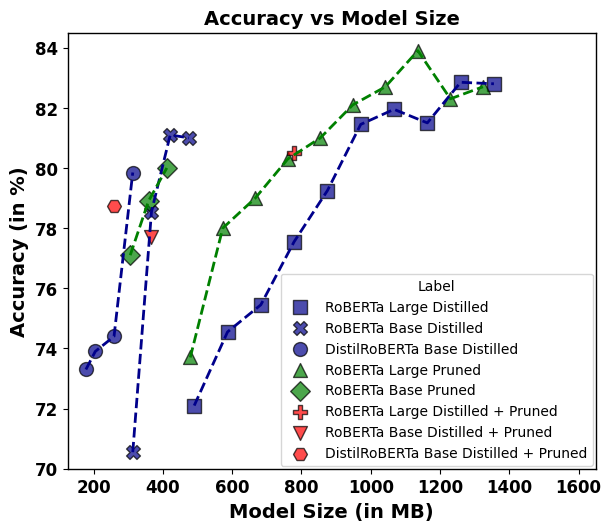

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import random

# ---------- Mapping for Shape based on individual label ----------
def get_marker_style(label):
    # Assign a unique marker for each label value
    markers = {
        'RoBERTa Large Distilled': 's',  # square
        'RoBERTa Base Distilled': 'X',  # x-shape
        'DistilRoBERTa Base Distilled': 'o',  # circle
        'RoBERTa Large Pruned': '^',  # triangle
        'RoBERTa Base Pruned': 'D',  # diamond
        'RoBERTa Large Distilled + Pruned': 'P',  # plus
        'RoBERTa Base Distilled + Pruned': 'v',  # star
        'DistilRoBERTa Base Distilled + Pruned': 'H'  # hexagon
    }
    return markers.get(label, 'o')  # Default to 'o' if label not found

# ---------- Mapping for Group → Color (manual dark colors) ----------
def get_color_group(label):
    if 'Distilled + Pruned' in label:
        return 'Distilled + Pruned'
    elif 'Pruned' in label:
        return 'Pruned'
    elif 'Distilled' in label:
        return 'Distilled'
    else:
        return 'Base'

# ---------- Color Palette for Groups (dark colors) ----------
group_to_color = {
    'Base': 'red',  # Black for Base
    'Distilled': 'darkblue',  # Dark Blue for Distilled
    'Pruned': 'green',  # Dark Red for Pruned
    'Distilled + Pruned': 'red'  # Black for Distilled + Pruned (same as Base)
}

# ---------- Specify Manual Label Order ----------
manual_label_order = [
    'RoBERTa Large Distilled', 'RoBERTa Base Distilled',
    'DistilRoBERTa Base Distilled', 'RoBERTa Large Pruned',
    'RoBERTa Base Pruned', 'RoBERTa Large Distilled + Pruned',
    'RoBERTa Base Distilled + Pruned',
    'DistilRoBERTa Base Distilled + Pruned'
]

# ---------- Plot Function ----------
def _plot_series(series, series_name, marker='o', color='blue'):
    xs = series['Model Size']
    ys = series['Accuracy']

    plt.scatter(xs, ys, label=series_name, color=color, marker=marker,
                edgecolor="black", s=100, alpha=0.7)
    plt.plot(xs, ys, color=color, linestyle="--", linewidth=2)

# ---------- Setup ----------
fig, ax = plt.subplots(figsize=(6, 5.2), layout='constrained')
df_sorted = final_df.sort_values('Layers', ascending=True)

# ---------- Plot Each Series with Manual Order ----------
for label in manual_label_order:
    series = df_sorted[df_sorted['label'] == label]
    marker = get_marker_style(label)
    color_group = get_color_group(label)
    color = group_to_color[color_group]
    _plot_series(series, label, marker=marker, color=color)

# ---------- Legend and Formatting ----------
fig.legend(title='Label', bbox_to_anchor=(0.99, 0.1), loc='lower right')

# Show all spines
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1)

# Labels
plt.xlabel('Model Size (in MB)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (in %)', fontsize=14, fontweight='bold')
plt.title("Accuracy vs Model Size", fontsize=14, fontweight='bold')
plt.xlim(125, 1650)
plt.ylim(70, 84.5)
# Tick labels with increased font size
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.show()


## 9.5 Accuracy vs. Inference Time Graph

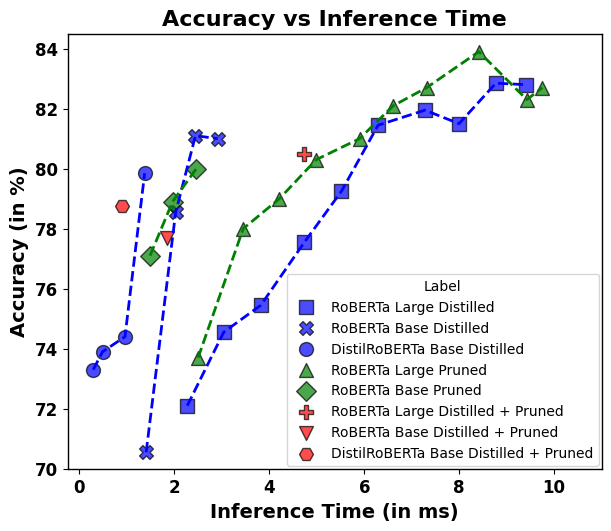

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import random

# ---------- Mapping for Shape based on individual label ----------
def get_marker_style(label):
    # Assign a unique marker for each label value
    markers = {
        'RoBERTa Large Distilled': 's',  # square
        'RoBERTa Base Distilled': 'X',  # x-shape
        'DistilRoBERTa Base Distilled': 'o',  # circle
        'RoBERTa Large Pruned': '^',  # triangle
        'RoBERTa Base Pruned': 'D',  # diamond
        'RoBERTa Large Distilled + Pruned': 'P',  # plus
        'RoBERTa Base Distilled + Pruned': 'v',  # star
        'DistilRoBERTa Base Distilled + Pruned': 'H'  # hexagon
    }
    return markers.get(label, 'o')  # Default to 'o' if label not found

# ---------- Mapping for Group → Color (manual dark colors) ----------
def get_color_group(label):
    if 'Distilled + Pruned' in label:
        return 'Distilled + Pruned'
    elif 'Pruned' in label:
        return 'Pruned'
    elif 'Distilled' in label:
        return 'Distilled'
    else:
        return 'Base'

# ---------- Color Palette for Groups (dark colors) ----------
group_to_color = {
    'Base': 'red',  # Black for Base
    'Distilled': 'blue',  # Dark Blue for Distilled
    'Pruned': 'green',  # Dark Red for Pruned
    'Distilled + Pruned': 'red'  # Black for Distilled + Pruned (same as Base)
}

# ---------- Specify Manual Label Order ----------
manual_label_order = [
    'RoBERTa Large Distilled', 'RoBERTa Base Distilled',
    'DistilRoBERTa Base Distilled', 'RoBERTa Large Pruned',
    'RoBERTa Base Pruned', 'RoBERTa Large Distilled + Pruned',
    'RoBERTa Base Distilled + Pruned',
    'DistilRoBERTa Base Distilled + Pruned'
]

# ---------- Plot Function ----------
def _plot_series(series, series_name, marker='o', color='blue'):
    xs = series['Inference Time']
    ys = series['Accuracy']

    plt.scatter(xs, ys, label=series_name, color=color, marker=marker,
                edgecolor="black", s=100, alpha=0.7)
    plt.plot(xs, ys, color=color, linestyle="--", linewidth=2)

# ---------- Setup ----------
fig, ax = plt.subplots(figsize=(6, 5.2), layout='constrained')
df_sorted = final_df.sort_values('Layers', ascending=True)

# ---------- Plot Each Series with Manual Order ----------
for label in manual_label_order:
    series = df_sorted[df_sorted['label'] == label]
    marker = get_marker_style(label)
    color_group = get_color_group(label)
    color = group_to_color[color_group]
    _plot_series(series, label, marker=marker, color=color)

# ---------- Legend and Formatting ----------
fig.legend(title='Label', bbox_to_anchor=(1, 0.1), loc='lower right')

# Show all spines
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1)

# Labels
plt.xlabel('Inference Time (in ms)')
plt.ylabel('Accuracy (in %)')
plt.title("Accuracy vs Inference Time")
plt.xlim(-0.25, 11)
plt.ylim(70, 84.5)

# Labels with increased font size
plt.xlabel('Inference Time (in ms)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (in %)', fontsize=14, fontweight='bold')
plt.title("Accuracy vs Inference Time", fontsize=16, fontweight='bold')

# Tick labels with increased font size
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.show()


## 9.6 Accuracy vs. Training Time

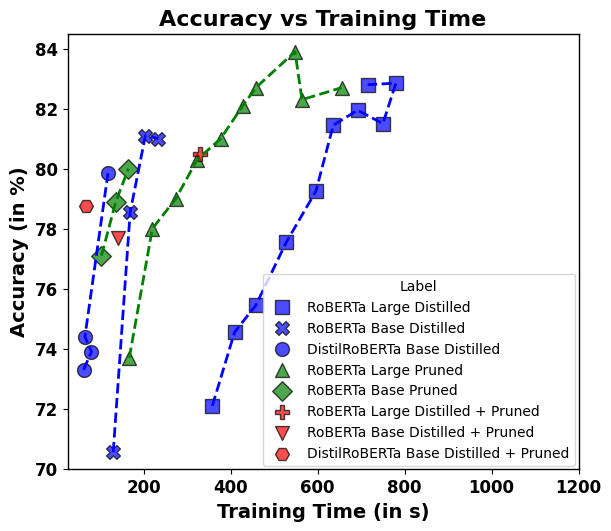

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import random

# ---------- Mapping for Shape based on individual label ----------
def get_marker_style(label):
    # Assign a unique marker for each label value
    markers = {
        'RoBERTa Large Distilled': 's',  # square
        'RoBERTa Base Distilled': 'X',  # x-shape
        'DistilRoBERTa Base Distilled': 'o',  # circle
        'RoBERTa Large Pruned': '^',  # triangle
        'RoBERTa Base Pruned': 'D',  # diamond
        'RoBERTa Large Distilled + Pruned': 'P',  # plus
        'RoBERTa Base Distilled + Pruned': 'v',  # star
        'DistilRoBERTa Base Distilled + Pruned': 'H'  # hexagon
    }
    return markers.get(label, 'o')  # Default to 'o' if label not found

# ---------- Mapping for Group → Color (manual dark colors) ----------
def get_color_group(label):
    if 'Distilled + Pruned' in label:
        return 'Distilled + Pruned'
    elif 'Pruned' in label:
        return 'Pruned'
    elif 'Distilled' in label:
        return 'Distilled'
    else:
        return 'Base'

# ---------- Color Palette for Groups (dark colors) ----------
group_to_color = {
    'Base': 'red',  # Black for Base
    'Distilled': 'blue',  # Dark Blue for Distilled
    'Pruned': 'green',  # Dark Red for Pruned
    'Distilled + Pruned': 'red'  # Black for Distilled + Pruned (same as Base)
}

# ---------- Specify Manual Label Order ----------
manual_label_order = [
    'RoBERTa Large Distilled', 'RoBERTa Base Distilled',
    'DistilRoBERTa Base Distilled', 'RoBERTa Large Pruned',
    'RoBERTa Base Pruned', 'RoBERTa Large Distilled + Pruned',
    'RoBERTa Base Distilled + Pruned',
    'DistilRoBERTa Base Distilled + Pruned'
]

# ---------- Plot Function ----------
def _plot_series(series, series_name, marker='o', color='blue'):
    xs = series['Training Time']
    ys = series['Accuracy']

    plt.scatter(xs, ys, label=series_name, color=color, marker=marker,
                edgecolor="black", s=100, alpha=0.7)
    plt.plot(xs, ys, color=color, linestyle="--", linewidth=2)

# ---------- Setup ----------
fig, ax = plt.subplots(figsize=(6, 5.2), layout='constrained')
df_sorted = final_df.sort_values('Layers', ascending=True)

# ---------- Plot Each Series with Manual Order ----------
for label in manual_label_order:
    series = df_sorted[df_sorted['label'] == label]
    marker = get_marker_style(label)
    color_group = get_color_group(label)
    color = group_to_color[color_group]
    _plot_series(series, label, marker=marker, color=color)

# ---------- Legend and Formatting ----------
fig.legend(title='Label', bbox_to_anchor=(0.96, 0.1), loc='lower right')

# Show all spines
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1)

# Labels
plt.xlabel('Training Time (in s)')
plt.ylabel('Accuracy (in %)')
plt.title("Accuracy vs Inference Time")
plt.xlim(25, 1200)
plt.ylim(70, 84.5)

# Labels with increased font size
plt.xlabel('Training Time (in s)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (in %)', fontsize=14, fontweight='bold')
plt.title("Accuracy vs Training Time", fontsize=16, fontweight='bold')

# Tick labels with increased font size
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.show()


## We congratulated ourselves because we are done!